In [11]:
import glob
import json
import os
import pandas as pd
import numpy as np

path_data = "../data"
path_result = "../result"
path_key = "../key"
path_evalkit = f"{path_data}/evalkits"
path_dependent = f"{path_data}/dependents"

evalware_list = """* [AlpacaEval](https://github.com/tatsu-lab/alpaca_eval) ![](https://img.shields.io/github/stars/tatsu-lab/alpaca_eval.svg?style=social) - AlpacaEval is an automatic evaluator for instruction-following language models.
* [ARES](https://github.com/stanford-futuredata/ARES) ![](https://img.shields.io/github/stars/stanford-futuredata/ARES.svg?style=social) - ARES is a framework for automatically evaluating Retrieval-Augmented Generation (RAG) models.
* [AutoML Benchmark](https://github.com/openml/automlbenchmark) ![](https://img.shields.io/github/stars/openml/automlbenchmark.svg?style=social) - AutoML Benchmark is a framework for evaluating and comparing open-source AutoML systems.
* [Banana-lyzer](https://github.com/reworkd/bananalyzer) ![](https://img.shields.io/github/stars/reworkd/bananalyzer.svg?style=social) - Banana-lyzer is an open source AI Agent evaluation framework and dataset for web tasks with Playwright.
* [Code Generation LM Evaluation Harness](https://github.com/bigcode-project/bigcode-evaluation-harness) ![](https://img.shields.io/github/stars/bigcode-project/bigcode-evaluation-harness.svg?style=social) - Code Generation LM Evaluation Harness is a framework for the evaluation of code generation models.
* [continuous-eval](https://github.com/relari-ai/continuous-eval) ![](https://img.shields.io/github/stars/relari-ai/continuous-eval.svg?style=social) - continuous-eval is a framework for data-driven evaluation of LLM-powered application.
* [DeepEval](https://github.com/confident-ai/deepeval) ![](https://img.shields.io/github/stars/confident-ai/deepeval.svg?style=social) - DeepEval is a simple-to-use, open-source evaluation framework for LLM applications.
* [EvalAI](https://github.com/Cloud-CV/EvalAI) ![](https://img.shields.io/github/stars/Cloud-CV/EvalAI.svg?style=social) - EvalAI is an open-source platform for evaluating and comparing AI algorithms at scale.
* [Evals](https://github.com/openai/evals) ![](https://img.shields.io/github/stars/openai/evals.svg?style=social) - Evals is a framework for evaluating OpenAI models and an open-source registry of benchmarks.
* [EvalScope](https://github.com/modelscope/evalscope) ![](https://img.shields.io/github/stars/modelscope/evalscope.svg?style=social) - EvalScope is a streamlined and customizable framework for efficient large model evaluation and performance benchmarking.
* [Evaluate](https://github.com/huggingface/evaluate) ![](https://img.shields.io/github/stars/huggingface/evaluate.svg?style=social) - Evaluate is a library that makes evaluating and comparing models and reporting their performance easier and more standardized.
* [Evalverse](https://github.com/UpstageAI/evalverse) ![](https://img.shields.io/github/stars/UpstageAI/evalverse.svg?style=social) - Evalverse is a framework to effortlessly evaluate and report LLMs with no-code requests and comprehensive reports.
* [Evidently](https://github.com/evidentlyai/evidently) ![](https://img.shields.io/github/stars/evidentlyai/evidently.svg?style=social) - Evidently is an open-source framework to evaluate, test and monitor ML and LLM-powered systems.
* [FlagEval](https://github.com/FlagOpen/FlagEval) ![](https://img.shields.io/github/stars/FlagOpen/FlagEval.svg?style=social) - FlagEval is an open-source evaluation toolkit as well as an open platform for evaluation of large models.
* [FMBench](https://github.com/aws-samples/foundation-model-benchmarking-tool) ![](https://img.shields.io/github/stars/aws-samples/foundation-model-benchmarking-tool.svg?style=social) - FMBench is a tool for running performance benchmarks for any Foundation Model (FM) deployed on any AWS Generative AI service, be it Amazon SageMaker, Amazon Bedrock, Amazon EKS, or Amazon EC2.
* [HarmBench](https://github.com/centerforaisafety/HarmBench) ![](https://img.shields.io/github/stars/centerforaisafety/HarmBench.svg?style=social) - HarmBench is a fast and scalable framework for evaluating automated red teaming methods and LLM attacks/defenses.
* [HELM](https://github.com/stanford-crfm/helm) ![](https://img.shields.io/github/stars/stanford-crfm/helm.svg?style=social) - HELM (Holistic Evaluation of Language Models) provides tools for the holistic evaluation of language models, including standardized datasets, a unified API for various models, diverse metrics, robustness, and fairness perturbations, a prompt construction framework, and a proxy server for unified model access.
* [Inspect](https://github.com/UKGovernmentBEIS/inspect_ai) ![](https://img.shields.io/github/stars/UKGovernmentBEIS/inspect_ai.svg?style=social) - Inspect is a framework for large language model evaluations.
* [InterCode](https://github.com/princeton-nlp/intercode) ![](https://img.shields.io/github/stars/princeton-nlp/intercode.svg?style=social) - InterCode is a lightweight, flexible, and easy-to-use framework for designing interactive code environments to evaluate language agents that can code.
* [Language Model Evaluation Harness](https://github.com/EleutherAI/lm-evaluation-harness) ![](https://img.shields.io/github/stars/EleutherAI/lm-evaluation-harness.svg?style=social) - Language Model Evaluation Harness is a framework to test generative language models on a large number of different evaluation tasks.
* [LightEval](https://github.com/huggingface/lighteval) ![](https://img.shields.io/github/stars/huggingface/lighteval.svg?style=social) - LightEval is a lightweight LLM evaluation suite.
* [LLMPerf](https://github.com/ray-project/llmperf) ![](https://img.shields.io/github/stars/ray-project/llmperf.svg?style=social) - LLMPerf is a tool for evaulation the performance of LLM APIs.
* [LLM AutoEval](https://github.com/mlabonne/llm-autoeval) ![](https://img.shields.io/github/stars/mlabonne/llm-autoeval.svg?style=social) - LLM AutoEval simplifies the process of evaluating LLMs using a convenient Colab notebook. You just need to specify the name of your model, a benchmark, a GPU, and press run!
* [lmms-eval](https://github.com/EvolvingLMMs-Lab/lmms-eval) ![](https://img.shields.io/github/stars/EvolvingLMMs-Lab/lmms-eval.svg?style=social) - lmms-eval is an evaluation framework meticulously crafted for consistent and efficient evaluation of LMM.
* [MLPerf Inference](https://github.com/mlcommons/inference) ![](https://img.shields.io/github/stars/mlcommons/inference.svg?style=social) - MLPerf Inference is a benchmark suite for measuring how fast systems can run models in a variety of deployment scenarios.
* [MTEB](https://github.com/embeddings-benchmark/mteb) ![](https://img.shields.io/github/stars/embeddings-benchmark/mteb.svg?style=social) - Massive Text Embedding Benchmark (MTEB) is a comprehensive benchmark of text embeddings.
* [OLMo-Eval](https://github.com/allenai/OLMo-Eval) ![](https://img.shields.io/github/stars/allenai/OLMo-Eval.svg?style=social) - OLMo-Eval is an evaluation suite for evaluating open language models.
* [OpenCompass](https://github.com/open-compass/OpenCompass) ![](https://img.shields.io/github/stars/open-compass/OpenCompass.svg?style=social) - OpenCompass is an LLM evaluation platform, supporting a wide range of models (LLaMA, LLaMa2, ChatGLM2, ChatGPT, Claude, etc) over 50+ datasets.
* [Opik](https://github.com/comet-ml/opik) ![](https://img.shields.io/github/stars/comet-ml/opik.svg?style=social) - Opik is an open-source platform for evaluating, testing and monitoring LLM applications.
* [Optimum-Benchmark](https://github.com/huggingface/optimum-benchmark) ![](https://img.shields.io/github/stars/huggingface/optimum-benchmark.svg?style=social) - A unified multi-backend utility for benchmarking Transformers and Diffusers with support for Optimum's arsenal of hardware optimizations/quantization schemes.
* [PhaseLLM](https://github.com/wgryc/phasellm) ![](https://img.shields.io/github/stars/wgryc/phasellm.svg?style=social) - PhaseLLM is a large language model evaluation and workflow framework.
* [Phoenix](https://github.com/Arize-ai/phoenix) ![](https://img.shields.io/github/stars/arize-ai/phoenix.svg?style=social) - Phoenix is an open-source AI observability platform designed for experimentation, evaluation, and troubleshooting.
* [PromptBench](https://github.com/microsoft/promptbench) ![](https://img.shields.io/github/stars/microsoft/promptbench.svg?style=social) - PromptBench is a unified evaluation framework for large language models
* [Prometheus-Eval](https://github.com/prometheus-eval/prometheus-eval) ![](https://img.shields.io/github/stars/prometheus-eval/prometheus-eval.svg?style=social) - Prometheus-Eval is a collection of tools for training, evaluating, and using language models specialized in evaluating other language models.
* [Ragas](https://github.com/explodinggradients/ragas) ![](https://img.shields.io/github/stars/explodinggradients/ragas.svg?style=social) - Ragas is a framework to evaluate RAG pipelines.
* [RAGChecker](https://github.com/amazon-science/RAGChecker) ![](https://img.shields.io/github/stars/amazon-science/RAGChecker.svg?style=social) - RAGChecker is an advanced automatic evaluation framework designed to assess and diagnose Retrieval-Augmented Generation (RAG) systems.
* [Rageval](https://github.com/gomate-community/rageval) ![](https://img.shields.io/github/stars/gomate-community/rageval.svg?style=social) - Rageval is a tool to evaluate RAG system.
* [RefChecker](https://github.com/amazon-science/RefChecker) ![](https://img.shields.io/github/stars/amazon-science/RefChecker.svg?style=social) - RefChecker provides a standardized assessment framework to identify subtle hallucinations present in the outputs of large language models (LLMs).
* [RewardBench](https://github.com/allenai/reward-bench) ![](https://img.shields.io/github/stars/allenai/reward-bench.svg?style=social) - RewardBench is a benchmark designed to evaluate the capabilities and safety of reward models.
* [TensorFlow Model Analysis](https://github.com/tensorflow/model-analysis) ![](https://img.shields.io/github/stars/tensorflow/model-analysis.svg?style=social) - TensorFlow Model Analysis (TFMA) is a library for evaluating TensorFlow models on large amounts of data in a distributed manner, using the same metrics defined in their trainer.
* [Tonic Validate](https://github.com/TonicAI/tonic_validate) ![](https://img.shields.io/github/stars/TonicAI/tonic_validate.svg?style=social) - Tonic Validate is a high-performance evaluation framework for LLM/RAG outputs.
* [TruLens](https://github.com/truera/trulens) ![](https://img.shields.io/github/stars/truera/trulens.svg?style=social) - TruLens provides fine-grained, stack-agnostic instrumentation and comprehensive evaluations towards LLM experiments.
* [TrustLLM](https://github.com/HowieHwong/TrustLLM) ![](https://img.shields.io/github/stars/HowieHwong/TrustLLM.svg?style=social) - TrustLLM is a comprehensive framework to evaluate the trustworthiness of large language models, which includes principles, surveys, and benchmarks.
* [UpTrain](https://github.com/uptrain-ai/uptrain) ![](https://img.shields.io/github/stars/uptrain-ai/uptrain.svg?style=social) - UpTrain is an open-source tool to evaluate LLM applications.
* [VBench](https://github.com/Vchitect/VBench) ![](https://img.shields.io/github/stars/Vchitect/VBench.svg?style=social) - VBench is a comprehensive benchmark suite for video generative models.
* [VLMEvalKit](https://github.com/open-compass/VLMEvalKit) ![](https://img.shields.io/github/stars/open-compass/VLMEvalKit.svg?style=social) - VLMEvalKit is an open-source evaluation toolkit of large vision-language models (LVLMs)."""

repo_mapping = {}
for line in evalware_list.split("\n"):
    parts = line.split("](")
    tool_name = parts[0].split("[")[1]
    repo_url = parts[1].split(")")[0]
    repo_name = repo_url.split(".com/")[-1]
    repo_mapping[tool_name] = repo_name

repo_mapping

{'AlpacaEval': 'tatsu-lab/alpaca_eval',
 'ARES': 'stanford-futuredata/ARES',
 'AutoML Benchmark': 'openml/automlbenchmark',
 'Banana-lyzer': 'reworkd/bananalyzer',
 'Code Generation LM Evaluation Harness': 'bigcode-project/bigcode-evaluation-harness',
 'continuous-eval': 'relari-ai/continuous-eval',
 'DeepEval': 'confident-ai/deepeval',
 'EvalAI': 'Cloud-CV/EvalAI',
 'Evals': 'openai/evals',
 'EvalScope': 'modelscope/evalscope',
 'Evaluate': 'huggingface/evaluate',
 'Evalverse': 'UpstageAI/evalverse',
 'Evidently': 'evidentlyai/evidently',
 'FlagEval': 'FlagOpen/FlagEval',
 'FMBench': 'aws-samples/foundation-model-benchmarking-tool',
 'HarmBench': 'centerforaisafety/HarmBench',
 'HELM': 'stanford-crfm/helm',
 'Inspect': 'UKGovernmentBEIS/inspect_ai',
 'InterCode': 'princeton-nlp/intercode',
 'Language Model Evaluation Harness': 'EleutherAI/lm-evaluation-harness',
 'LightEval': 'huggingface/lighteval',
 'LLMPerf': 'ray-project/llmperf',
 'LLM AutoEval': 'mlabonne/llm-autoeval',
 'lmms-e

In [122]:
# import openai

# # Load OpenAI token from a JSON file
# with open(f'{path_key}/.openai.json') as f:
#     openai.api_key = json.load(f)['login_or_token']

# # Load the CSV file into a DataFrame
# df = pd.read_csv('/Users/jimmy/Downloads/thesamplesformanualanalysis/GH_pull_random_sample.csv')  # Replace 'your_file.csv' with your actual file name

# # Function to summarize a message
# def summarize_message(message):
#     response = openai.chat.completions.create(
#         model="gpt-4-turbo",  # or "gpt-4" if available
#         messages=[
#             {"role": "system", "content": "Try your best to summarize the following message in 2-3 words, omit any uninformational details."},
#             {"role": "user", "content": f"Summarize the following pull request in a 'verb (original format) + subject' format in 2-3 words: {message}"}
#         ],
#         temperature=0,
#         max_tokens=20,  # Enough for a short phrase
#         n=1,
#         stop=None,
#     )

#     return response.choices[0].message.content.strip()

# # Apply the function to the 'reduced_mssg' attribute of each row and create a new column 'summary'
# df['label_zhimin'] = df['reduced_mssg'].apply(summarize_message)

# # for index, row in df.iterrows():
# #     message = summarize_message(row['reduced_mssg'])
# #     df.at[index, 'label_zhimin'] = message
# #     print(message)
# #     if index % 10 == 9:
# #         break

# # Optionally, save the DataFrame with the new summaries back to a CSV
# df.to_csv('GH_pull_random_sample_labeled.csv', index=False)  # Replace 'summarized_output.csv' with your desired output file name

In [94]:
# from collections import Counter

# repo_collection = []
# for line in text.split('\n'):
#     if '](' in line:
#         parts = line.split('](')
#         tool_name = parts[0].split('[')[1]
#         repo_collection.append(tool_name)

# repo_mapping = Counter(repo_collection)
# repo_mapping

In [93]:
# for line in text.split('\n'):
#   if 'github.com' not in line:
#     continue
#   try:
#     parts = line.split('](')
#     repo_url = parts[1].split(')')[0]
#     repo_name = repo_url.split('.com/')[-1]
#     badge_url = parts[2].split('.svg')[0]
#     badge_name = badge_url.split('stars/')[-1]
#     # print(repo_name)
#     if repo_name != badge_name:
#       print(repo_name, badge_name)
#   except:
#     pass

In [14]:
from github import Github
from github import Auth

# Load GitHub token from a JSON file
with open(f"{path_key}/.github.json") as f:
    github_token = json.load(f)["login_or_token"]
    auth = Auth.Token(github_token)
    g = Github(auth=auth)

# Initialize an empty list to store repository information
repo_data = []

for tool_name, repo_name in repo_mapping.items():
    try:
        repo = g.get_repo(repo_name)

        # Get basic repository attributes
        created_at = repo.created_at
        num_contributors = repo.get_contributors().totalCount
        num_stars = repo.stargazers_count
        num_subscribers = repo.subscribers_count
        num_commits = repo.get_commits().totalCount
        num_pull_requests = repo.get_pulls(state="all").totalCount
        num_issues = repo.get_issues(state="all").totalCount
        num_forks = repo.forks_count

        # # Get fork information
        # forks = repo.get_forks()
        # fork_data = {}
        # num_forks = 0

        # for fork in forks:
        #     num_forks += 1
        #     # Get the number of commits for each fork
        #     try:
        #         fork_commits = fork.get_commits().totalCount
        #         if fork_commits > 0:
        #             fork_data[fork.full_name] = fork_commits
        #     except Exception as e:
        #         print(f"Error retrieving commits for fork {fork.full_name}: {e}")
        #         fork_data[fork.full_name] = "Error"

        # Store all the collected data in a dictionary
        repo_info = {
            "tool_name": tool_name,
            "repository": repo.full_name,
            "created_at": created_at,
            "num_contributors": num_contributors,
            "num_stars": num_stars,
            "num_subscribers": num_subscribers,
            "num_forks": num_forks,
            "num_commits": num_commits,
            "num_pull_requests": num_pull_requests,
            "num_issues": num_issues,
            "labels": [label.name for label in repo.get_labels()],
            # 'fork_commits_mapping': fork_data
        }

        repo_data.append(repo_info)

    except Exception as e:
        print(f"Error retrieving data for repository {repo_name}: {e}")

# Convert the list of dictionaries to a pandas DataFrame
df = pd.DataFrame(repo_data)

# # Add a column for the number of technical forks
# df['num_technical_forks'] = df['fork_commits_mapping'].apply(len)

# Sort the columns alphabetically
df = df[sorted(df.columns)]

# Save the DataFrame to a JSON file
df.to_json(f"{path_data}/evalkits.json", orient="records", lines=True)

print("Data has been successfully saved to 'evalkits.json'.")

Following Github server redirection from /repos/FlagOpen/FlagEval to /repositories/577569592


Data has been successfully saved to 'evalkits.json'.


In [25]:
import plotly.graph_objects as go

df = pd.read_json(f"{path_data}/evalkits.json", lines=True)

# # Create a box plot
# fig = go.Figure()

# fig.add_trace(go.Box(
#     y=df['num_dependents'],
#     name="Evalkits",
#     boxmean=True  # Shows mean in the box plot
# ))

# # Customize layout
# fig.update_layout(
#     yaxis_title="Number of Dependents for Evalkits",
#     yaxis_type="log"  # Set y-axis to logarithmic scale
# )

# # Show plot
# fig.show()

# Create a box plot
fig = go.Figure()

fig.add_trace(
    go.Box(
        y=df["num_forks"], name="Evalkits", boxmean=True  # Shows mean in the box plot
    )
)

# Customize layout
fig.update_layout(
    yaxis_title="Number of Technical Forks for Evalkits",
    yaxis_type="log",  # Set y-axis to logarithmic scale
)

# Show plot
fig.show()

# Create a box plot
fig = go.Figure()

fig.add_trace(
    go.Box(
        y=df["num_issues"], name="Evalkits", boxmean=True  # Shows mean in the box plot
    )
)

# Customize layout
fig.update_layout(
    yaxis_title="Number of Issues for Evalkits",
    yaxis_type="log",  # Set y-axis to logarithmic scale
)

# Show plot
fig.show()

# Create a box plot
fig = go.Figure()

fig.add_trace(
    go.Box(
        y=df["num_pull_requests"],
        name="Evalkits",
        boxmean=True,  # Shows mean in the box plot
    )
)

# Customize layout
fig.update_layout(
    yaxis_title="Number of PRs for Evalkits",
    yaxis_type="log",  # Set y-axis to logarithmic scale
)

# Show plot
fig.show()

In [95]:
from github import Github
from github import Auth

# Load GitHub token from a JSON file
with open(f"{path_key}/.github.json") as f:
    github_token = json.load(f)["login_or_token"]
    auth = Auth.Token(github_token)
    g = Github(auth=auth)

# File paths for the consolidated JSON files
pull_requests_file = f"{path_data}/pull_requests.json"
commits_file = f"{path_data}/commits.json"
issues_file = f"{path_data}/issues.json"


def resolve_commit_author(commit):
    try:
        return commit.author.login
    except:
        return commit.commit.raw_data["author"]["name"]


def process_repository(repo_name):
    repo = g.get_repo(repo_name)

    # Process commits
    commits = []
    for _, commit in enumerate(repo.get_commits()):
        commits.append(
            {
                "repository": repo_name,
                "link": commit.html_url,
                "message": commit.commit.message,
                "contributor_id": resolve_commit_author(commit),
                "creation_time": commit.commit.author.date,
            }
        )

    # Append commits to file
    if commits:
        commit_df = pd.DataFrame(commits)
        commit_df.to_json(commits_file, orient="records", lines=True, mode="a")
        print(f"Processed {repo_name} commits.")

    # Process issues
    issues = []
    pull_requests = []
    for _, issue in enumerate(repo.get_issues(state="all")):
        if not issue.pull_request:
            issues.append(
                {
                    "repository": repo_name,
                    "link": issue.html_url,
                    "message": issue.title,
                    "contributor_id": issue.user.login,
                    "creation_time": issue.created_at,
                    "labels": [label.name for label in issue.labels],
                    "state": issue.state,
                }
            )
        else:
            pull_requests.append(
                {
                    "repository": repo_name,
                    "link": issue.html_url,
                    "message": issue.title,
                    "contributor_id": issue.user.login,
                    "creation_time": issue.created_at,
                    "labels": [label.name for label in issue.labels],
                    "state": issue.state,
                }
            )

    # Append issues to file
    if issues:
        issues_df = pd.DataFrame(issues)
        issues_df.to_json(issues_file, orient="records", lines=True, mode="a")
        print(f"Processed {repo_name} issues.")

    # Append pull requests to file
    if pull_requests:
        pr_df = pd.DataFrame(pull_requests)
        pr_df.to_json(pull_requests_file, orient="records", lines=True, mode="a")
        print(f"Processed {repo_name} pull requests.")


# Process each repository
for repo in ["EleutherAI/lm-evaluation-harness"]:  # repo_mapping.values():
    try:
        process_repository(repo)
        print(f"Processed {repo} successfully.")
    except Exception as e:
        print(f"Error processing {repo}: {str(e)}")

print("All repositories processed and data saved.")

Processed amazon-science/RAGChecker pull requests.
Processed amazon-science/RAGChecker commits.
Processed amazon-science/RAGChecker issues.
Processed amazon-science/RAGChecker successfully.
All repositories processed and data saved.


In [15]:
import plotly.express as px

# Load the JSON file
commits_file = f"{path_data}/commits.json"
df = pd.read_json(commits_file, lines=True)

# Group by contributor_id to find the number of unique repositories and total commits
contrib_repos = (
    df.groupby("contributor_id")["repository"]
    .nunique()
    .reset_index(name="num_repositories")
)
contrib_commits = (
    df.groupby("contributor_id")["repository"].count().reset_index(name="num_commits")
)

# Merge the two DataFrames to get a summary for each contributor
contrib_summary = pd.merge(contrib_repos, contrib_commits, on="contributor_id")

# Aggregate the data by the number of repositories and number of commits
repos_distribution = contrib_summary["num_repositories"].value_counts().reset_index()
repos_distribution.columns = ["num_repositories", "count"]

commits_distribution = contrib_summary["num_commits"].value_counts().reset_index()
commits_distribution.columns = ["num_commits", "count"]

# Create a bar chart for the number of repositories with log scale
fig_repos = px.bar(
    repos_distribution,
    x="num_repositories",
    y="count",
    title="Distribution of Contributors by Number of Repositories (Log Scale)",
    labels={
        "num_repositories": "Number of Repositories",
        "count": "Number of Contributors",
    },
    log_y=True,
)

# Create a bar chart for the number of commits with log scale
fig_commits = px.bar(
    commits_distribution,
    x="num_commits",
    y="count",
    title="Distribution of Contributors by Number of Commits (Log Scale)",
    labels={"num_commits": "Number of Commits", "count": "Number of Contributors"},
    log_x=True,
    log_y=True,
)

fig_repos.show()
fig_commits.show()

import ineqpy

# Calculate the Gini coefficient for the number of repositories
gini_repos = ineqpy.inequality.gini(repos_distribution["count"].values)
print(
    f"The Gini coefficient for the number of repositories across different contributors is {gini_repos}."
)

# Calculate the Gini coefficient for the number of commits
gini_commits = ineqpy.inequality.gini(commits_distribution["count"].values)
print(
    f"The Gini coefficient for the number of commits across different contributors is {gini_commits}."
)

The Gini coefficient for the number of repositories across different contributors is 0.9786851566512583.
The Gini coefficient for the number of commits across different contributors is 0.8886448327486902.


In [16]:
# Load the JSON file
commits_file = f"{path_data}/pull_requests.json"
df = pd.read_json(commits_file, lines=True)

# Group by contributor_id to find the number of unique repositories and total pull requests
contrib_repos = (
    df.groupby("contributor_id")["repository"]
    .nunique()
    .reset_index(name="num_repositories")
)
contrib_commits = (
    df.groupby("contributor_id")["repository"]
    .count()
    .reset_index(name="num_pull_requests")
)

# Merge the two DataFrames to get a summary for each contributor
contrib_summary = pd.merge(contrib_repos, contrib_commits, on="contributor_id")

# Aggregate the data by the number of repositories and number of pull requests
repos_distribution = contrib_summary["num_repositories"].value_counts().reset_index()
repos_distribution.columns = ["num_repositories", "count"]

commits_distribution = contrib_summary["num_pull_requests"].value_counts().reset_index()
commits_distribution.columns = ["num_pull_requests", "count"]

# Create a bar chart for the number of repositories with log scale
fig_repos = px.bar(
    repos_distribution,
    x="num_repositories",
    y="count",
    title="Distribution of Contributors by Number of Repositories (Log Scale)",
    labels={
        "num_repositories": "Number of Repositories",
        "count": "Number of Contributors",
    },
    log_y=True,
)

# Create a bar chart for the number of pull requests with log scale
fig_commits = px.bar(
    commits_distribution,
    x="num_pull_requests",
    y="count",
    title="Distribution of Contributors by Number of Pull Requests (Log Scale)",
    labels={
        "num_pull_requests": "Number of Pull Requests",
        "count": "Number of Contributors",
    },
    log_x=True,
    log_y=True,
)

fig_repos.show()
fig_commits.show()

import ineqpy

# Calculate the Gini coefficient for the number of repositories
gini_repos = ineqpy.inequality.gini(repos_distribution["count"].values)
print(
    f"The Gini coefficient for the number of repositories across different contributors is {gini_repos}."
)

# Calculate the Gini coefficient for the number of pull requests
gini_commits = ineqpy.inequality.gini(commits_distribution["count"].values)
print(
    f"The Gini coefficient for the number of pull requests across different contributors is {gini_commits}."
)

The Gini coefficient for the number of repositories across different contributors is 0.9861682242990655.
The Gini coefficient for the number of pull requests across different contributors is 0.9298493229067297.


In [8]:
issues_file = f"{path_data}/issues.json"
df_issues = pd.read_json(issues_file, lines=True)

pull_requests_file = f"{path_data}/pull_requests.json"
df_pull_requests = pd.read_json(pull_requests_file, lines=True)

issues_label = df_issues["labels"].explode().dropna().unique().tolist()
pull_requests_label = df_pull_requests["labels"].explode().dropna().unique().tolist()

labels = [label.lower() for label in issues_label] + [
    label.lower() for label in pull_requests_label
]
labels = sorted(list(set(labels)))
labels

['3 points',
 '5 points',
 'additions',
 'answered',
 'asking questions',
 'automation',
 'aws',
 'backend',
 'backlog',
 'benchmark design',
 'bias',
 'bug',
 'bug:p0',
 'bug:p1',
 'bug_fix',
 'can-be-merged',
 'ci',
 'cla: no',
 'cla: yes',
 'cleanup',
 'code-upload',
 'competition',
 'container',
 'continuous integration',
 'cpu',
 'critical',
 'data',
 'data add',
 'dataset',
 'declined',
 'dependencies',
 'dependent',
 'deployment',
 'devinfra',
 'docs',
 'documentation',
 'duplicate',
 'easy-medium',
 'easy_to_fix',
 'enhancement',
 'external',
 'feature',
 'feature request',
 'fixed-in-next-release',
 'framework',
 'framework add',
 'frontend',
 'frontend_v2',
 'general',
 'generic discussion',
 'good first issue',
 'gpu',
 'gsoc-2019',
 'gsoc-2020',
 'gsoc-2021',
 'gsoc-2022',
 'gsoc-2023',
 'gsoc-2024',
 'hacktoberfest',
 'hacktoberfest-accepted',
 'hard-to-fix',
 'harms',
 'heim (text2image)',
 'help wanted',
 'high priority',
 'idea for eval',
 'improvement',
 'in progress',

In [26]:
label_categories = {
    "bug": ["bug", "bug:p0", "bug:p1", "bug_fix", "minor issue", "type:bug"],
    "documentation": ["docs", "documentation", "type:docs"],
    "duplicate": ["duplicate"],
    "enhancement": [
        "enhancement",
        "feature",
        "feature request",
        "new-feature",
        "planned feature",
        "improvement",
        "type:feature",
    ],
    "good first issue": ["good first issue", "easy-medium", "easy_to_fix"],
    "help wanted": [
        "help wanted",
        "needs reviewer",
        "opinions wanted",
        "hacktoberfest",
        "hacktoberfest-accepted",
    ],
    "invalid": ["invalid", "not_validated", "declined"],
    "question": [
        "question",
        "user question",
        "more-information-needed",
        "asking questions",
    ],
    "wontfix": ["wontfix", "out of scope", "stale"],
}
category_labels = {
    label: category for category, labels in label_categories.items() for label in labels
}

In [27]:
import plotly.express as px


# Function to get categories from labels
def get_categories_from_labels(labels):
    categories = set()
    for label in labels:
        if label in category_labels:
            categories.add(category_labels[label])
    if not categories:
        return pd.NA
    else:
        return categories.pop()


issues_file = f"{path_data}/issues.json"
df_issues = pd.read_json(issues_file, lines=True)

# Apply the function to the data
df_issues["category"] = df_issues["labels"].apply(get_categories_from_labels)

# Get the distribution of categories
category_distribution = df_issues["category"].value_counts().reset_index()

# Create bar chart using Plotly
fig = px.bar(category_distribution, x="category", y="count")

# Update layout for better readability
fig.update_layout(
    xaxis_tickangle=-45,
    xaxis_title="Category",
    yaxis_title="Issue Counts [with Labels]",
)

# Show the plot
fig.show()

In [56]:
import openai
import pandas as pd
from tenacity import (
    retry,
    wait_exponential,
    stop_after_attempt,
    retry_if_exception_type,
)
import time

# Load OpenAI token from a JSON file
with open(f"{path_key}/.openai.json") as f:
    openai.api_key = json.load(f)["api_key"]

# Load the JSON file into a DataFrame
issues_file = f"{path_data}/issues.json"
df = pd.read_json(issues_file, lines=True)


# Define a custom exception for handling request limits
class RateLimitError(Exception):
    pass


# Function to summarize a message with retry logic
@retry(
    wait=wait_exponential(multiplier=1, min=4, max=60),
    stop=stop_after_attempt(5),
    retry=retry_if_exception_type(RateLimitError),
)
def categorize_message(message):
    try:
        response = openai.chat.completions.create(
            model="gpt-4o",  # or "gpt-4" if available
            messages=[
                {
                    "role": "system",
                    "content": "There are nine categories for classifying GitHub issues:\n1. **bug**: A problem where something isn't working as expected.\n2. **documentation**: Suggestions or requests for improving documentation.\n3. **duplicate**: This issue or pull request has already been reported.\n4. **enhancement**: A request for a new feature or improvement.\n5. **good first issue**: A task suitable for newcomers.\n6. **help wanted**: The issue requires additional assistance or expertise.\n7. **invalid**: The issue is not valid or doesn't seem correct.\n8. **question**: A request for further clarification or information.\n9. **wontfix**: This issue will not be addressed.\nIf none of the categories fit, choose 0. Given an issue description, respond with the index number (0-9) that best categorizes the issue. Return only the index number and nothing else.",
                },
                {
                    "role": "user",
                    "content": f"The description is: ###{message}###\nThe category index is: ",
                },
            ],
            temperature=0,
            max_tokens=5,  # Enough for a short phrase
            n=1,
            stop=None,
        )
        answer = response.choices[0].message.content.strip()
        print(answer)

        return answer

    except openai.error.RateLimitError:
        # Handle rate limit error
        time.sleep(60)  # Wait for a minute before retrying
        raise RateLimitError


# Apply the function to the 'message' attribute of each row and create a new column 'category'
df["category"] = df["message"].apply(categorize_message)
df["category"] = df["category"].apply(int)

# Save the updated DataFrame back to the JSON file
df.to_json(issues_file, orient="records", lines=True)

8
4
4
4
4
2
4
4
1
4
8
1
4
4
8
1
8
1
4
4
2
4
4
4
4
1
4
1
0
8
1
4
4
4
4
1
4
1
1
4
1
1
4
4
2
4
4
8
4
1
8
1
1
8
1
8
4
0
2
4
4
1
1
8
4
1
4
4
4
4
4
4
4
4
8
2
0
4
8
4
1
0
1
4
4
8
4
8
2
8
8
4
4
4
1
1
4
4
4
2
1
2
4
8
2
4
8
1
8
4
2
4
1
1
8
4
4
8
1
1
8
4
2
4
4
4
4
8
4
4
1
4
0
4
4
8
4
4
1
4
4
4
4
4
4
4
4
4
4
4
4
4
1
4
1
4
4
4
2
0
2
4
4
1
4
4
4
8
0
4
1
4
4
4
4
4
1
2
0
8
4
4
4
4
1
4
1
4
1
1
1
4
1
0
4
4
4
4
4
0
0
4
2
4
4
0
0
4
0
4
8
4
2
4
4
4
1
1
8
4
4
1
1
4
8
4
1
8
1
4
4
0
1
4
8
0
8
4
4
4
8
0
4
4
4
4
4
4
4
0
4
4
4
4
8
4
1
0
1
4
4
4
1
4
4
4
4
4
2
2
4
4
1
4
4
8
8
1
1
4
2
1
4
2
4
4
0
4
8
8
4
2
0
1
4
4
4
4
4
4
4
8
4
4
4
4
4
4
4
4
1
4
4
1
4
4
4
4
4
0
4
0
0
1
4
1
4
4
4
4
4
4
4
4
0
0
4
4
4
4
0
4
2
4
4
4
4
4
4
4
4
1
4
4
4
4
0
8
8
4
4
8
4
4
4
8
1
0
8
1
0
1
0
2
4
4
0
2
4
0
2
4
4
4
4
7
4
2
4
2
2
1
1
1
8
8
1
8
1
0
8
1
4
8
8
1
1
4
1
1
1
1
1
1
0
1
2
4
2
4
4
4
4
4
4
4
4
4
2
1
2
2
1
2
4
1
2
8
2
4
7
4
4
4
4
4
4
4
4
4
4
4
4
4
4
8
4
0
0
4
4
4
2
1
2
2
1
1
8
4
0
2
4
1
2
4
4
4
4
1
1
4
4
4
1
8
4
2
1
8
4
1
2
1
4
4
0
4
4
4


In [60]:
import re
import spacy
from bs4 import BeautifulSoup
from collections import namedtuple, Counter
from gensim.parsing.preprocessing import (
    remove_stopwords,
    strip_numeric,
    strip_punctuation,
    STOPWORDS,
)

# import subprocess
# subprocess.run(['python', '-m' 'spacy', 'download', 'en_core_web_sm'])
nlp = spacy.load("en_core_web_sm")

stop_words_se = {
    "ability",
    "abilities",
    "accident",
    "accidents",
    "acknowledgement",
    "action",
    "actions",
    "activities",
    "activity",
    "advantage",
    "advantages",
    "advice",
    "ai",
    "alternative",
    "alternatives",
    "announcement",
    "announcements",
    "anomaly", 
    "anomalies",
    "answer",
    "answers",
    "appreciation",
    "approach",
    "approaches",
    "article",
    "articles",
    "assistance",
    "attempt",
    "author",
    "behavior",
    "behaviour",
    "benefit",
    "benefits",
    "bit",
    "bits",
    "block",
    "blocks",
    "blog",
    "blogs",
    "body",
    "building",
    "case",
    "cases",
    "categories",
    "categorization",
    "category",
    "cause",
    "causes",
    "challenge",
    "challenges",
    "change",
    "changes",
    # 'char',
    "check",
    "choice",
    "choices",
    "clarification",
    "code",
    "collection",
    "com",
    "combination",
    # 'commmunication',
    # 'community',
    # 'communities',
    # 'company',
    # 'companies',
    # 'computer',
    # 'computers',
    # 'concept',
    # 'concepts',
    "concern",
    "concerns",
    # 'condition',
    # 'conditions',
    "confirmation",
    "confusion",
    "consideration",
    # 'content',
    # 'contents',
    "context",
    # 'count',
    "couple",
    "couples",
    "course",
    "courses",
    "cross",
    # 'custom',
    "day",
    "days",
    "demand",
    "description",
    "descriptions",
    "desire",
    "detail",
    "details",
    "devops",
    "difference",
    "differences",
    "difficulties",
    "difficulty",
    "disadvantage",
    "disadvantages",
    "discrepancies",
    "discrepancy",
    "discussion",
    "discussions",
    "dislike",
    "distinction",
    "effect",
    "end",
    # 'engineering',
    "enquiries",
    "enquiry",
    "evidence",
    "example",
    "examples",
    "exception",
    "exceptions",
    "existence",
    "exit",
    "expectation",
    "experience",
    "expert",
    "experts",
    "explanation",
    "explanations",
    "fact",
    "facts",
    "favorite",
    "favorites",
    # 'feature',
    # 'features',
    "feedback",
    "feedbacks",
    "fix",
    "fixes",
    # 'float',
    # 'form',
    # 'forms',
    "forum" "forums"
    # 'functionality',
    # 'functionalities',
    "future",
    "goal",
    "goals",
    "guarantee",
    "guidance",
    "guideline",
    "guide",
    "guides",
    "guy",
    "guys",
    "harm",
    "hello",
    "help",
    "hour",
    "hours",
    "ibm",
    "idea",
    "ideas",
    "individual",
    "individuals",
    "info",
    "information",
    "inquiries",
    "inquiry",
    "insight",
    "instruction",
    "instructions",
    # 'int',
    "intelligence",
    "intent",
    "interest",
    "introduction",
    "investigation",
    "invitation",
    "ipynb",
    "issue",
    "issues",
    "kind",
    "kinds",
    "lack",
    "learning",
    "level",
    "levels",
    "look",
    "looks",
    "lot",
    "lots",
    "luck",
    "machine",
    "major",
    "manner",
    "manners",
    "manual",
    "mark",
    "means",
    "meaning",
    # 'message',
    # 'messages',
    "method",
    "methods",
    "ml",
    "mlops",
    "minute",
    "minutes",
    "month",
    "months",
    "need",
    "needs",
    "number",
    "numbers",
    "offer",
    "one",
    "ones",
    "opinion",
    "opinions",
    # 'org',
    # 'organization',
    # 'organizations',
    "outcome",
    "part",
    "parts",
    "past",
    "people",
    "person",
    "persons",
    "perspective",
    "perspectives",
    "place",
    "places",
    "point",
    "points",
    "post",
    "posts",
    "practice",
    "practices",
    "problem",
    "problems",
    "product",
    "products",
    "program",
    "programs",
    "project",
    "projects",
    "proposal",
    "proposals",
    "purpose",
    "purposes",
    "py",
    # 'python',
    "qa",
    "question",
    "questions",
    "reason",
    "reasons",
    # 'research',
    "result",
    "results",
    "scenario",
    "scenarios",
    "science",
    "screenshot",
    "screenshots",
    "second",
    "seconds",
    "section",
    "sense",
    "shortcoming",
    "shortcomings",
    "show",
    "shows",
    "situation",
    "software",
    "solution",
    "solutions",
    "start",
    # 'state',
    # 'statement',
    # 'states',
    # 'status',
    # 'step',
    # 'steps',
    # 'string',
    # 'student',
    # 'students',
    "study",
    "stuff",
    "success",
    "suggestion",
    "suggestions",
    "summary",
    "summaries",
    "surprise",
    "support",
    "supports",
    "talk",
    "talks",
    "task",
    "tasks",
    # 'teacher',
    # 'teachers',
    # 'team',
    # 'teams',
    "technique",
    "techniques",
    "technologies",
    "technology",
    "term",
    "terms",
    "tip",
    "tips",
    "thank",
    "thanks",
    "thing",
    "things",
    "thought",
    "thoughts",
    "three",
    "title",
    "today",
    "tomorrow",
    # 'tool',
    # 'tools',
    "total",
    "trouble",
    "troubles",
    "truth",
    "try",
    "tutorial",
    "tutorials",
    "two",
    "understand",
    "understanding",
    "usage",
    "use",
    "user",
    "users",
    "uses",
    # 'value',
    # 'values',
    "view",
    "viewpoint",
    "way",
    "ways",
    "weakness",
    "weaknesses",
    "week",
    "weeks",
    "word",
    "words",
    "work",
    "workaround",
    "workarounds",
    "works",
    "yeah",
    "year",
    "years",
    "yesterday",
}

error_words_basics = {
    "break",
    "bug",
    "ceas",
    "clos",
    "crash",
    "defect",
    "error",
    "fail",
    "fault",
    "fix",
    "finish",
    "flaw",
    "glitch",
    "halt",
    "malfunction",
    "mistak",
    "paus",
    "shutdown",
    "stop",
    "terminat",
}

stop_words = STOPWORDS.union(stop_words_se)


def count_code_line(block_list):
    total_loc = 0
    for block in block_list:
        for line in block.splitlines():
            if line.strip():
                total_loc += 1
    return total_loc


def extract_styles(content):
    soup = BeautifulSoup(content, "html.parser")
    # extract links
    links = [a["href"] for a in soup.find_all("a", href=True)]
    # extract code blocks type 1
    code_line1 = count_code_line([c.get_text() for c in soup.find_all("code")])
    # extract code blocks type 2
    code_line2 = count_code_line([c.get_text() for c in soup.find_all("blockquote")])
    # extract text
    for tag in soup.find_all(["code", "blockquote", "a"]):
        tag.decompose()
    clean_text = soup.get_text(separator=" ")
    return clean_text, links, code_line1 + code_line2


def extract_code(content):
    code_patterns = [r"```.+?```", r"``.+?``", r"`.+?`"]
    clean_text = content
    code_line = 0

    for code_pattern in code_patterns:
        code_snippets = re.findall(code_pattern, clean_text, flags=re.DOTALL)
        code_line += count_code_line(code_snippets)
        clean_text = re.sub(code_pattern, "", clean_text, flags=re.DOTALL)

    return clean_text, code_line


def extract_links(text):
    link_pattern1 = r"\!?\[.*?\]\((.*?)\)"
    links1 = re.findall(link_pattern1, text)
    clean_text = re.sub(link_pattern1, "", text)
    link_pattern2 = r"http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+"
    links2 = re.findall(link_pattern2, clean_text)
    clean_text = re.sub(link_pattern2, "", clean_text)
    links = links1 + links2
    return clean_text, links


def split_content(content):
    clean_text, links1, code_line1 = extract_styles(content)
    clean_text, code_line2 = extract_code(clean_text)
    clean_text, links2 = extract_links(clean_text)

    links = links1 + links2
    code_line = code_line1 + code_line2

    content_collection = namedtuple("Analyzer", ["text", "links", "code_line"])
    return content_collection(clean_text, links, code_line)


def extract_nouns_verbs(text, verb):
    doc = nlp(text)
    if verb:
        words = [
            token.text
            for token in doc
            if (token.pos_ == "VERB") or (token.pos_ == "NOUN")
        ]
    else:
        words = [token.text for token in doc if token.pos_ == "NOUN"]
    return " ".join(words)


def remove_words_with_substring(text, substring_list):
    words = text.split()
    for substring in substring_list:
        words = [word for word in words if substring not in word]
    return " ".join(words)


def remove_escape_characters(s):
    return re.sub(r"\\.", " ", s)


def preprocess_text(text, verb=True):
    clean_text = text.lower()
    clean_text = clean_text.encode("ascii", "ignore").decode("ascii")
    clean_text = remove_escape_characters(clean_text)
    clean_text = strip_punctuation(clean_text)
    clean_text = strip_numeric(clean_text)
    clean_text = remove_words_with_substring(clean_text, error_words_basics)
    clean_text = extract_nouns_verbs(clean_text, verb)
    clean_text = remove_stopwords(clean_text, stop_words)
    return clean_text

In [67]:
issues_file = f"{path_data}/issues.json"
df = pd.read_json(issues_file, lines=True)

for index, row in df.iterrows():
    original_text = split_content(row["message"]).text
    df.at[index, "preprocessed_message"] = preprocess_text(original_text)

df.to_json(issues_file, orient="records", lines=True)

/var/folders/p7/fg_w39cx6pq23vf3798tdmq00000gn/T/ipykernel_2398/1684129366.py:408: MarkupResemblesLocatorWarning:

The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.



In [68]:
commits_file = f"{path_data}/commits.json"
df = pd.read_json(commits_file, lines=True)

for index, row in df.iterrows():
    original_text = split_content(row["message"]).text
    df.at[index, "preprocessed_message"] = preprocess_text(original_text)

df.to_json(commits_file, orient="records", lines=True)

/var/folders/p7/fg_w39cx6pq23vf3798tdmq00000gn/T/ipykernel_2398/1684129366.py:408: MarkupResemblesLocatorWarning:

The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.



In [69]:
pull_requests_file = f"{path_data}/pull_requests.json"
df = pd.read_json(pull_requests_file, lines=True)

for index, row in df.iterrows():
    original_text = split_content(row["message"]).text
    df.at[index, "preprocessed_message"] = preprocess_text(original_text)

df.to_json(pull_requests_file, orient="records", lines=True)

/var/folders/p7/fg_w39cx6pq23vf3798tdmq00000gn/T/ipykernel_2398/1684129366.py:408: MarkupResemblesLocatorWarning:

The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.



In [12]:
import subprocess

# Load the environment variables from key.json
with open(f"{path_key}/.sourcegraph.json") as f:
    env_vars = json.load(f)

# Set the environment variables
os.environ.update(env_vars)

# Execute the shell script and pass path_data as an argument
try:
    subprocess.run(
        ["sh", f"{path_dependent}/Dependents_Lookup.sh", path_dependent], check=True
    )
    print("Script executed successfully.")
except subprocess.CalledProcessError as e:
    print(f"Script execution failed with error: {e}")

Script executed successfully.


In [15]:
evalkits = pd.read_json(f"{path_data}/evalkits.json", lines=True)
evalkit_repo_mapping = dict(zip(evalkits["tool_name"], evalkits["repository"]))

repo_dependents = {}
repo_num_dependents = {}
total_dependents = 0
for file in glob.glob(f"{path_dependent}/*.json"):
    with open(file) as f:
        data = json.load(f)
        if "SourcegraphEndpoint" in data:
            repo_names = [
                repo["name"].split("github.com/")[-1] for repo in data["Results"]
            ]
        else:
            repo_names = [repo["name"] for repo in data["all_public_dependent_repos"]]
        evalkit_name = file.split("/")[-1].split(".")[0]
        repo_names = list(set(repo_names) - set(evalkit_repo_mapping[evalkit_name]))
        repo_dependents[evalkit_name] = repo_names
        repo_num_dependents[evalkit_name] = len(repo_names)
        total_dependents += len(repo_names)

evalkit_dependents = pd.DataFrame(
    list(repo_dependents.items()), columns=["Evalkit", "Dependent"]
)
evalkit_dependents["Evalkit"] = evalkit_dependents["Evalkit"].map(evalkit_repo_mapping)
evalkit_dependents.to_json(
    f"{path_data}/dependent_mapping.json", orient="records", lines=True
)

print(f"Total number of dependents: {total_dependents}")
sorted(repo_num_dependents.items(), key=lambda x: x[1], reverse=True)

Total number of dependents: 13742


[('Evaluate', 10059),
 ('Ragas', 803),
 ('Language Model Evaluation Harness', 719),
 ('VBench', 524),
 ('EvalAI', 403),
 ('OpenCompass', 235),
 ('DeepEval', 172),
 ('AlpacaEval', 147),
 ('MTEB', 146),
 ('Optimum-Benchmark', 114),
 ('Evals', 87),
 ('lmms-eval', 44),
 ('LLMPerf', 42),
 ('TensorFlow Model Analysis', 36),
 ('Phoenix', 33),
 ('Evidently', 25),
 ('HELM', 18),
 ('Code Generation LM Evaluation Harness', 16),
 ('VLMEvalKit', 13),
 ('FMBench', 12),
 ('Evalverse', 11),
 ('LLM AutoEval', 9),
 ('ARES', 7),
 ('Tonic Validate', 6),
 ('UpTrain', 6),
 ('Inspect', 5),
 ('LightEval', 5),
 ('EvalScope', 4),
 ('AutoML Benchmark', 4),
 ('TruLens', 4),
 ('RewardBench', 4),
 ('Opik', 3),
 ('OLMo-Eval', 3),
 ('MLPerf Inference', 3),
 ('HarmBench', 3),
 ('PhaseLLM', 2),
 ('Prometheus-Eval', 2),
 ('continuous-eval', 2),
 ('RAGChecker', 2),
 ('RefChecker', 2),
 ('Banana-lyzer', 2),
 ('FlagEval', 1),
 ('InterCode', 1),
 ('TrustLLM', 1),
 ('Rageval', 1),
 ('PromptBench', 1)]

In [10]:
# evalkits = pd.read_json(f'{path_data}/evalkits.json', lines=True)
# evalkit_repo_mapping = dict(zip(evalkits['tool_name'], evalkits['repository']))

# repo_dependents = {}
# repo_num_dependents = {}
# total_dependents = 0
# for file in glob.glob(f'{path_dependent}/*.json'):
#     with open(file) as f:
#         data = json.load(f)
#         if 'SourcegraphEndpoint' in data:
#             repo_names = [repo['name'].split('github.com/')[-1] for repo in data['Results']]
#         else:
#             continue
#         evalkit_name = file.split('/')[-1].split('.')[0]
#         repo_names = list(set(repo_names) - set(evalkit_repo_mapping[evalkit_name]))
#         repo_dependents[evalkit_name] = repo_names
#         repo_num_dependents[evalkit_name] = len(repo_names)
#         total_dependents += len(repo_names)

# print(f'The total number of dependents across all repositories is {total_dependents}.')
# sorted(repo_num_dependents.items(), key=lambda x: x[1], reverse=True)

The total number of dependents across all repositories is 2560.


[('Language Model Evaluation Harness', 719),
 ('VBench', 524),
 ('EvalAI', 403),
 ('OpenCompass', 235),
 ('AlpacaEval', 147),
 ('Optimum-Benchmark', 114),
 ('Evals', 87),
 ('lmms-eval', 44),
 ('LLMPerf', 42),
 ('TensorFlow Model Analysis', 36),
 ('Phoenix', 33),
 ('Evidently', 25),
 ('HELM', 18),
 ('Code Generation LM Evaluation Harness', 16),
 ('VLMEvalKit', 13),
 ('FMBench', 12),
 ('Evalverse', 11),
 ('LLM AutoEval', 9),
 ('ARES', 7),
 ('Tonic Validate', 6),
 ('UpTrain', 6),
 ('Inspect', 5),
 ('LightEval', 5),
 ('EvalScope', 4),
 ('AutoML Benchmark', 4),
 ('TruLens', 4),
 ('RewardBench', 4),
 ('Opik', 3),
 ('OLMo-Eval', 3),
 ('MLPerf Inference', 3),
 ('HarmBench', 3),
 ('PhaseLLM', 2),
 ('Prometheus-Eval', 2),
 ('RAGChecker', 2),
 ('RefChecker', 2),
 ('Banana-lyzer', 2),
 ('FlagEval', 1),
 ('InterCode', 1),
 ('TrustLLM', 1),
 ('Rageval', 1),
 ('PromptBench', 1)]

In [79]:
# from github import Github
# from github import Auth

# # Load GitHub token from a JSON file
# with open(f'{path_key}/.github.json') as f:
#     github_token = json.load(f)['login_or_token']
#     auth = Auth.Token(github_token)
#     g = Github(auth=auth)

# repo = 'huggingface/optimum-benchmark'
# repo_name = repo.split('/')[-1]
# # File paths for the consolidated JSON files
# issues_file = f"{path_data}/issues_{repo_name}.json"

# def process_repository(repo_name):
#     repo = g.get_repo(repo_name)

#     # Process issues
#     issues = []
#     for _, issue in enumerate(repo.get_issues(state='all')):
#         if not issue.pull_request:
#             issues.append({
#                 'repository': repo_name,
#                 'link': issue.html_url,
#                 'message': issue.title,
#                 'body': issue.body
#             })

#     # Append issues to file
#     if issues:
#         issues_df = pd.DataFrame(issues)
#         issues_df.to_json(issues_file, orient='records', lines=True, mode='a')
#         print(f'Processed {repo_name} issues.')

# process_repository(repo)

Processed huggingface/optimum-benchmark issues.


In [81]:
# import re
# import webbrowser

# def extract_links(text):
#     link_pattern1 = r"\!?\[.*?\]\((.*?)\)"
#     links1 = re.findall(link_pattern1, text)
#     clean_text = re.sub(link_pattern1, '', text)
#     link_pattern2 = r"http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+"
#     links2 = re.findall(link_pattern2, clean_text)
#     clean_text = re.sub(link_pattern2, '', clean_text)
#     links = links1 + links2
#     return clean_text, links

# df_issues = pd.read_json(f'{path_data}/issues_{repo_name}.json', lines=True)
# df = pd.DataFrame()
# for index, row in df_issues.iterrows():
#     if pd.isna(row['body']):
#         continue
#     links = extract_links(row['body'])[1]
#     links = [link for link in links if ('https://github.com/' in link) and (repo not in link) and (len(link.split('/')) == 5)]
#     if links:
#         df = pd.concat([df, row.to_frame().T], ignore_index=True)
#         webbrowser.open(row['link'])

# print(len(df['link'].tolist()))

1


In [10]:
import subprocess


def git_clone(repo_url, clone_dir=None, token=None):
    """
    Clones a given Git repository, with optional authentication using a GitHub token.

    Args:
    repo_url (str): The URL of the Git repository.
    clone_dir (str, optional): The directory to clone the repository into. Defaults to the current directory.
    token (str, optional): The GitHub personal access token for authentication (if needed for private repos).

    Returns:
    bool: True if the clone was successful, False otherwise.
    """
    try:
        # If a token is provided, add it to the repository URL
        if token:
            protocol, repo_path = repo_url.split("://")
            repo_url = f"{protocol}://{token}@{repo_path}"

        # Build the git clone command
        if clone_dir:
            result = subprocess.run(["git", "clone", repo_url, clone_dir], check=True)
        else:
            result = subprocess.run(["git", "clone", repo_url], check=True)

        if result.returncode == 0:
            print(f"Successfully cloned {repo_url}")
            return True
        else:
            print(f"Failed to clone {repo_url}")
            return False
    except subprocess.CalledProcessError as e:
        print(f"Error occurred: {e}")
        return False


df_evalkits = pd.read_json(f"{path_data}/evalkits.json", lines=True)

for index, row in df_evalkits.iterrows():
    repo_url = f"https://github.com/{row['repository']}"
    git_clone(repo_url, f"{path_evalkit}/{row['tool_name']}")

Cloning into '../data/repositories/AlpacaEval'...
Updating files: 100% (1018/1018), done.
Cloning into '../data/repositories/ARES'...


Successfully cloned https://github.com/tatsu-lab/alpaca_eval


Updating files: 100% (205/205), done.
Cloning into '../data/repositories/AutoML Benchmark'...


Successfully cloned https://github.com/stanford-futuredata/ARES
Successfully cloned https://github.com/openml/automlbenchmark


Cloning into '../data/repositories/Banana-lyzer'...
Updating files: 100% (374/374), done.


...

Successfully cloned https://github.com/uptrain-ai/uptrain


Cloning into '../data/repositories/VBench'...


Successfully cloned https://github.com/Vchitect/VBench


Cloning into '../data/repositories/VLMEvalKit'...


Successfully cloned https://github.com/open-compass/VLMEvalKit


In [32]:
false_postive_mapping = [
    {"dependent": "Code Generation LM Evaluation Harness", "dependency": "Optimum-Benchmark"},
    {"dependent": "VLMEvalKit", "dependency": "OpenCompass"},
    {"dependent": "Ragas", "dependency": "Phoenix"},
    {"dependent": "VLMEvalKit", "dependency": "VBench"},
    {"dependent": "HarmBench", "dependency": "VBench"},
    {"dependent": "lmms-eval", "dependency": "VBench"},
    {"dependent": "EvalScope", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "Code Generation LM Evaluation Harness", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "HELM", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "lmms-eval", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "Phoenix", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "FMBench", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "OLMo-Eval", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "LightEval", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "Tonic Validate", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "OpenCompass", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "Evidently", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "Inspect", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "HarmBench", "dependency": "AlpacaEval"},
    {"dependent": "Prometheus-Eval", "dependency": "AlpacaEval"},
    {"dependent": "RewardBench", "dependency": "AlpacaEval"},
    {"dependent": "Evalverse", "dependency": "Evaluate"},
    {"dependent": "Ragas", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "Opik", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "continuous-eval", "dependency": "Ragas"},
    {"dependent": "continuous-eval", "dependency": "Optimum-Benchmark"}
]

false_negative_mapping = [
    {
        "dependent": "RAGChecker",
        "dependency": "Ragas", 
    }
]

df_evalkits = pd.read_json(f"{path_data}/evalkits.json", lines=True)
evalkit_repo_mapping = dict(zip(df_evalkits["repository"], df_evalkits["tool_name"]))
df_evalkit_dependents = pd.read_json(f"{path_data}/dependent_mapping.json", lines=True)

dependency_mappings = false_negative_mapping
for index, row in df_evalkit_dependents.iterrows():
    dependency = evalkit_repo_mapping[row["Evalkit"]]
    for dependent in row["Dependent"]:
        try:
            dependent = evalkit_repo_mapping[dependent]
            if dependency != dependent:
                # Check if the pair exists in the false_positive_mapping
                if not any(
                    fp["dependent"] == dependent and fp["dependency"] == dependency
                    for fp in false_postive_mapping
                ):
                    dependency_mappings.append(
                        {
                            "dependent": dependent,
                            "dependency": dependency,
                        }
                    )
        except:
            pass

dependency_mappings_labeled = [
    {
        "dependent": "OpenCompass",
        "dependency": "AlpacaEval",
        "usages": ["evaluation backend"],
        "references": [
            "https://github.com/open-compass/opencompass/blob/6997990c932e4b0eed32029450ad7e9fb750e022/opencompass/tasks/outer_eval/alpacaeval.py#L141"
        ],
    },
    {
        "dependent": "LLM AutoEval",
        "dependency": "Language Model Evaluation Harness",
        "usages": ["evaluation backend"],
        "references": [
            "https://github.com/mlabonne/llm-autoeval/blob/eca29921dd3a2d8397289f3132ba1dce5837e9cf/runpod.sh#L98"
        ],
    },
    {
        "dependent": "EvalScope",
        "dependency": "OpenCompass",
        "usages": ["evaluation backend"],
        "references": [
            "https://github.com/modelscope/evalscope?tab=readme-ov-file#evaluation-backend"
        ],
    },
    {
        "dependent": "DeepEval",
        "dependency": "Ragas",
        "usages": ["evaluation backend", "metric loader"],
        "references": [
            "https://github.com/confident-ai/deepeval/blob/d2c0e6fa53b299bcd0598b65f795639b78bc7a57/deepeval/metrics/ragas.py#L35",
            "https://github.com/confident-ai/deepeval/blob/d2c0e6fa53b299bcd0598b65f795639b78bc7a57/deepeval/metrics/ragas.py#L36",
        ],
    },
    {
        "dependent": "UpTrain",
        "dependency": "Evals",
        "usages": ["evaluation backend"],
        "references": ["https://github.com/uptrain-ai/uptrain/blob/a31cc14eddcb6c0b0b12cbed15f086d98c441c6f/uptrain/operators/language/openai_evals.py#L8"],
    },
    {
        "dependent": "EvalScope",
        "dependency": "VLMEvalKit",
        "usages": ["evaluation backend"],
        "references": [
            "https://github.com/modelscope/evalscope/blob/8649aaf1722cda995e9a2294ee734038be170dde/evalscope/backend/vlm_eval_kit/backend_manager.py#L22"
        ],
    },
    {
        "dependent": "OpenCompass",
        "dependency": "VLMEvalKit",
        "usages": ["model instantiation"],
        "references": [
            "https://github.com/open-compass/opencompass/blob/5b93592242235fec4c5a9e1bc2a57cfd33a77e15/opencompass/datasets/cibench.py#L241"
        ],
    },
    {
        "dependent": "RAGChecker",
        "dependency": "RefChecker",
        "usages": ["knowledge extractor", "claim checker"],
        "references": [
            "https://github.com/amazon-science/RAGChecker/blob/038584e0b7e11a681da6749a0e29c0faab75e9c1/ragchecker/evaluator.py#L4C34-L4C46",
            "https://github.com/amazon-science/RAGChecker/blob/038584e0b7e11a681da6749a0e29c0faab75e9c1/ragchecker/evaluator.py#L79C28-L79C38",
        ],  # https://github.com/amazon-science/RefChecker/blob/c575b538039913504dace32124787c71325600f6/refchecker/extractor/llm_extractor.py#L14C1-L171C27, https://github.com/amazon-science/RefChecker/blob/c575b538039913504dace32124787c71325600f6/refchecker/checker/llm_checker.py#L11
    },
    {
        "dependent": "TruLens",
        "dependency": "Optimum-Benchmark",
        "usages": ["orphaned dependency"],
        "references": [
            "https://github.com/truera/trulens/blob/8a554d7440686b30db290efcd45dadf897e064c7/src/providers/huggingface/poetry.lock#L1804"
        ],
    },
    {
        "dependent": "LLM AutoEval",
        "dependency": "LightEval",
        "usages": ["evaluation backend"],
        "references": [
            "https://github.com/mlabonne/llm-autoeval/blob/eca29921dd3a2d8397289f3132ba1dce5837e9cf/runpod.sh#L176"
        ],
    },
    {
        "dependent": "HarmBench",
        "dependency": "Evaluate",
        "usages": ["transitive dependency"],
        "references": [
            "https://github.com/centerforaisafety/HarmBench/blob/8e1604d1171fe8a48d8febecd22f600e462bdcdd/adversarial_training/alignment-handbook/scripts/adv_training_utils.py#L316"
        ],
    },
    {
        "dependent": "Code Generation LM Evaluation Harness",
        "dependency": "Evaluate",
        "usages": ["metric loader"],
        "references": [
            "https://github.com/bigcode-project/bigcode-evaluation-harness/blob/f0b81a9d079289881bd42f509811d42fe73e58cf/bigcode_eval/tasks/apps.py#L118"
        ],
    },
    {
        "dependent": "Ragas",
        "dependency": "Opik", 
        "usages": ["log tracer"], 
        "references": ["https://github.com/explodinggradients/ragas/blob/78b54c6dca6e14dea6d7412274f6601b26a7c175/src/ragas/integrations/opik.py#L20"]
    },
    {
        "dependent": "TruLens",
        "dependency": "Evaluate",
        "usages": ["metric loader"],
        "references": [
            "https://github.com/truera/trulens/blob/8a554d7440686b30db290efcd45dadf897e064c7/src/feedback/trulens/feedback/groundtruth.py#L359"
        ],
    },
    {
        "dependent": "Evidently",
        "dependency": "Evaluate",
        "usages": ["metric loader"],
        "references": [
            "https://github.com/evidentlyai/evidently/blob/29dca00db5959f20da98193cb0c9fdafda9daa97/src/evidently/features/hf_feature.py#L117"
        ],
    },
    {
        "dependent": "Evalverse",
        "dependency": "Language Model Evaluation Harness",
        "usages": ["evaluation backend"],
        "references": [
            "https://github.com/UpstageAI/evalverse/blob/06f85eefd4b82385c549ea3bc29ff3e177f3a84b/evalverse/connector.py#L32",
        ],
    },
    {
        "dependent": "Language Model Evaluation Harness",
        "dependency": "Evaluate",
        "usages": ["metric loader", "transitive dependency"],
        "references": [
            "https://github.com/EleutherAI/lm-evaluation-harness/blob/543617fef9ba885e87f8db8930fbbff1d4e2ca49/lm_eval/tasks/noticia/utils.py#L44",
            "https://github.com/EleutherAI/lm-evaluation-harness/blob/543617fef9ba885e87f8db8930fbbff1d4e2ca49/lm_eval/models/huggingface.py#L201",
        ],
    },
    {
        "dependent": "OpenCompass",
        "dependency": "Evaluate",
        "usages": ["metric loader", "transitive dependency", "metric implementation"],
        "references": [
            "https://github.com/open-compass/opencompass/blob/b5f8afb57b428887af7f8b2a2d3c41f99756f23a/opencompass/datasets/medbench/medbench.py#L399",
            "https://github.com/open-compass/opencompass/blob/b5f8afb57b428887af7f8b2a2d3c41f99756f23a/opencompass/models/modelscope.py#L165",
            "https://github.com/open-compass/opencompass/blob/b5f8afb57b428887af7f8b2a2d3c41f99756f23a/opencompass/openicl/icl_evaluator/hf_metrics/accuracy.py#L80",
        ],
    },
    {
        "dependent": "lmms-eval",
        "dependency": "Evaluate",
        "usages": ["metric loader", "transitive dependency"],
        "references": [
            "https://github.com/EvolvingLMMs-Lab/lmms-eval/blob/35d221f5d66d4412b8c002a117b69847f44d7f70/lmms_eval/api/registry.py#L117",
            "https://github.com/EvolvingLMMs-Lab/lmms-eval/blob/35d221f5d66d4412b8c002a117b69847f44d7f70/lmms_eval/models/video_chatgpt/eval/model_utils.py#L130",
        ],
    },
    {
        "dependent": "ARES",
        "dependency": "Evaluate",
        "usages": ["metric loader"],
        "references": [
            "https://github.com/stanford-futuredata/ARES/blob/4aa2a248a5c8c8f1ca0bce5724cda16d7edda6f7/ares/RAG_Automatic_Evaluation/LLMJudge_RAG_Compared_Scoring.py#L635"
        ],
    },
    {
        "dependent": "MLPerf Inference",
        "dependency": "Evaluate",
        "usages": ["metric loader", "transitive dependency"],
        "references": [
            "https://github.com/mlcommons/inference/blob/81c2de69de4af90410cd1ba000fc5bd731bf6dee/language/gpt-j/evaluation.py#L48",
            "https://github.com/mlcommons/inference/blob/81c2de69de4af90410cd1ba000fc5bd731bf6dee/language/bert/pytorch_SUT.py#L58",
        ],
    },
    {
        "dependent": "Evals",
        "dependency": "Evaluate",
        "usages": ["metric loader", "transitive dependency"],
        "references": [
            "https://github.com/openai/evals/blob/234bcde34b5951233681455faeb92baaaef97573/evals/elsuite/multistep_web_tasks/webarena/evaluation_harness/evaluators.py#L150",
            "https://github.com/openai/evals/blob/234bcde34b5951233681455faeb92baaaef97573/evals/elsuite/hr_ml_agent_bench/benchmarks/imdb/env/train.py#L21",
        ],
    },
    {
        "dependent": "RAGChecker",
        "dependency": "Ragas", 
        "usages": ["benchmark generation"], 
        "references": ["https://github.com/amazon-science/RAGChecker/blob/038584e0b7e11a681da6749a0e29c0faab75e9c1/scripts/synthesize_benchmark.py#L4"]
    }
]


def compare_mapping_list_by_difference(list1, list2):
    # Function to check if two dictionaries are the same by 'dependent' and 'dependency'
    def dicts_equal_by_keys(dict1, dict2):
        return dict1.get("dependent") == dict2.get("dependent") and dict1.get(
            "dependency"
        ) == dict2.get("dependency")

    # Find elements in list1 that are not in list2
    diff1 = [d for d in list1 if not any(dicts_equal_by_keys(d, d2) for d2 in list2)]

    # Find elements in list2 that are not in list1
    diff2 = [d for d in list2 if not any(dicts_equal_by_keys(d, d2) for d2 in list1)]

    # Return differentiated elements
    return diff1, diff2

df = pd.DataFrame(dependency_mappings_labeled)
df.to_json(f"{path_data}/evalkit_mapping.json", orient="records", lines=True)

compare_mapping_list_by_difference(dependency_mappings, dependency_mappings_labeled)

([], [])

Total number of edges: 31


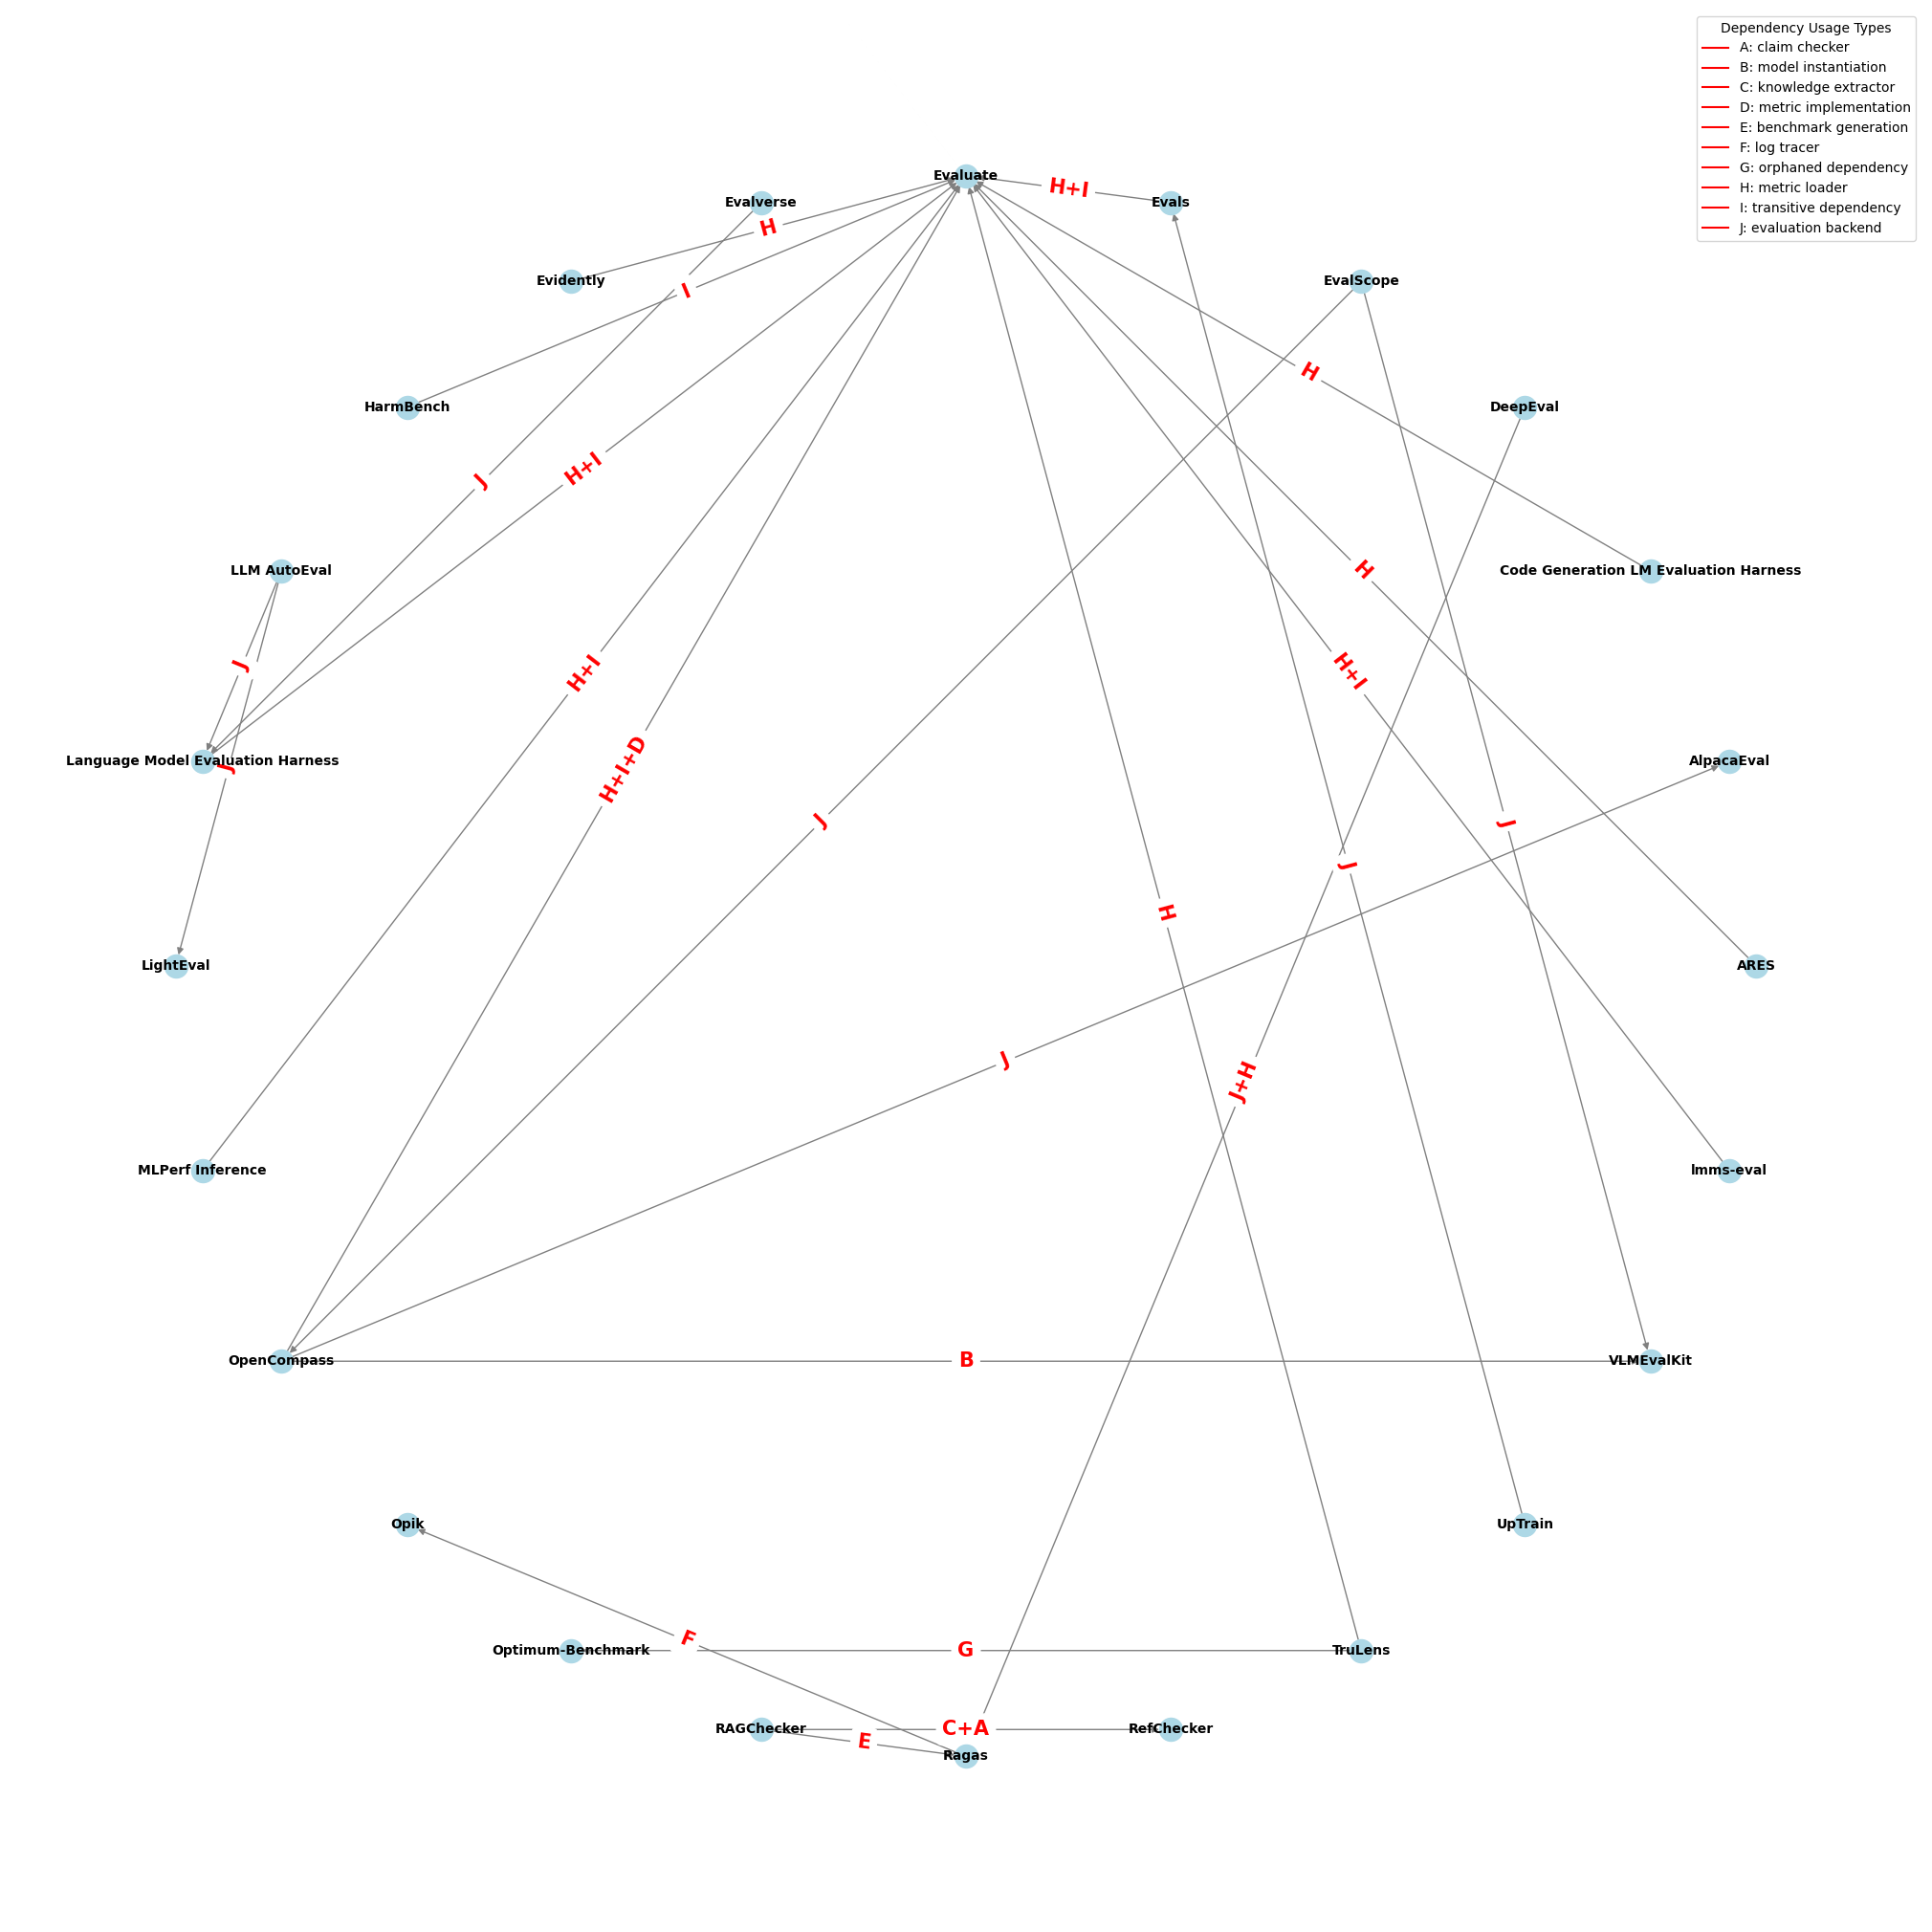

In [33]:
import networkx as nx
import matplotlib.pyplot as plt
import string
import plotly.graph_objects as go
import numpy as np

# Create a directed graph (DiGraph to avoid multi-edges)
G = nx.DiGraph()

# Extract all unique usages from dependency_mappings_labeled
unique_usages = set()
for mapping in dependency_mappings_labeled:
    unique_usages.update(mapping["usages"])

# Automatically map unique usage types to uppercase letters
usage_to_label = {
    usage: letter for usage, letter in zip(unique_usages, string.ascii_uppercase)
}

# Add edges with combined usage annotations
edge_labels = {}

# Collect nodes and sort them alphabetically
all_nodes = set()
for mapping in dependency_mappings_labeled:
    all_nodes.add(mapping["dependent"])
    all_nodes.add(mapping["dependency"])

sorted_nodes = sorted(all_nodes)  # Sort nodes alphabetically

# Rebuild dependency_mappings_labeled in sorted order of nodes (optional)
sorted_mappings = sorted(
    dependency_mappings_labeled, key=lambda x: (x["dependent"], x["dependency"])
)

edge_count = 0
# Add sorted edges with combined usage annotations
for mapping in sorted_mappings:
    dependent = mapping["dependent"]
    dependency = mapping["dependency"]
    usages = mapping["usages"]

    # Combine all usage labels for a single edge
    usage_labels = [usage_to_label[usage] for usage in usages]
    combined_label = "+".join(usage_labels)

    # Add edge with the combined label
    G.add_edge(dependent, dependency)

    # Store the edge label for displaying
    edge_labels[(dependent, dependency)] = combined_label

    edge_count += len(usages)

print(f"Total number of edges: {edge_count}")

# Increase figure size
plt.figure(figsize=(20, 20))

# Arrange nodes in a circular layout with sorted alphabetical order
n = len(sorted_nodes)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False)

# Create the position dictionary where nodes are placed in alphabetical order
pos = {
    node: (np.cos(angle), np.sin(angle)) for node, angle in zip(sorted_nodes, angles)
}

# Draw the graph with nodes and edges
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=300,
    font_size=10,
    font_weight="bold",
    edge_color="gray",
    arrows=True,
    font_color="black",
)

# Draw the edge labels (annotations) with enlarged size and red color
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels, font_color="red", font_weight="bold", font_size=15
)

# Create a custom legend for the usage types
legend_labels = {label: usage for usage, label in usage_to_label.items()}
handles = [
    plt.Line2D([0], [0], color="red", label=f"{label}: {usage}")
    for label, usage in legend_labels.items()
]
plt.legend(handles=handles, title="Dependency Usage Types")

# Show the directed graph plot
plt.show()

# ---- Bar Chart with Plotly ----

# Count occurrences of each unique usage
usage_counts = {usage: 0 for usage in unique_usages}
for mapping in dependency_mappings_labeled:
    for usage in mapping["usages"]:
        usage_counts[usage] += 1

# Sort the usage counts in descending order
sorted_usage_counts = dict(
    sorted(usage_counts.items(), key=lambda item: item[1], reverse=True)
)

# Create bar chart using Plotly
fig = go.Figure(
    data=[
        go.Bar(
            name="Usage Count",
            x=list(sorted_usage_counts.keys()),
            y=list(sorted_usage_counts.values()),
        )
    ]
)

# Update layout for better visibility
fig.update_layout(
    title="Distribution of Dependency Usage Types between Harnessess",
    xaxis_title="Usage Type",
    yaxis_title="Count",
    template="plotly_white",
)

# Display the bar chart
fig.show()

In [ ]:
# df = pd.read_json(f"{path_data}/evalkits.json", lines=True)
# df2 = df.copy()

# implicit_dependency_mapping_labeled = []
# for index, row in df.iterrows():
#     for index2, row2 in df2.iterrows():
#         implicit_dependency_mapping = {
#         "dependent": row["tool_name"],
#         "dependency": row2["tool_name"],
#         "usages": [],
#         "references": [],
#         }
#         implicit_dependency_mapping_labeled.append(implicit_dependency_mapping)

# implicit_dependency_mapping_labeled

In [37]:
implicit_dependency_mapping_labeled = [
    {
        "dependency": "AlpacaEval", 
        "dependent": "HarmBench", 
        "usages": ["benchmark recommendation"], 
        "references": ["https://github.com/centerforaisafety/HarmBench/blob/8e1604d1171fe8a48d8febecd22f600e462bdcdd/adversarial_training/alignment-handbook/scripts/README.md?plain=1#L112"]
    },
    # {
    #     "dependency": "AlpacaEval", 
    #     "dependent": "OpenCompass", 
    #     "usages": ["evaluation class", "evaluation dataset"], 
    #     "references": ["https://github.com/open-compass/opencompass/blob/cfbd308edf2e2aa2b86e4275c7278dafaf611a44/opencompass/tasks/outer_eval/alpacaeval.py#L77", "https://github.com/open-compass/opencompass/blob/cfbd308edf2e2aa2b86e4275c7278dafaf611a44/opencompass/utils/datasets_info.py#L360"]
    # },
    {
        "dependency": "AlpacaEval",
        "dependent": "Prometheus-Eval",
        "usages": ["evaluation dataset"],
        "references": ["https://github.com/prometheus-eval/prometheus-eval/blob/b7a431a553b320e0a7cc49c6c5d3c54b1b840d39/eval/benchmark/data_loader.py#L21"],
    },
    {
        "dependency": "AlpacaEval", 
        "dependent": "RewardBench", 
        "usages": ["format conversion", "evaluation dataset"], 
        "references": ["https://github.com/allenai/reward-bench/blob/82bd441dc54190da54d230a67e4d6d7076568b1d/analysis/bon_to_alpacaeval.py#L15", "https://github.com/allenai/reward-bench/blob/82bd441dc54190da54d230a67e4d6d7076568b1d/rewardbench/utils.py#L407"]
    },
    {
        "dependency": "ARES", 
        "dependent": "RAGChecker", 
        "usages": ["evaluation metric"], 
        "references": ["https://github.com/amazon-science/RAGChecker/blob/038584e0b7e11a681da6749a0e29c0faab75e9c1/data/meta_evaluation/meta_eval.py#L25"]
    },
    {
        "dependency": "ARES", 
        "dependent": "Rageval", 
        "usages": ["prompt reference"], 
        "references": ["https://github.com/gomate-community/rageval/blob/c25311497aace256806fe4565858594026a2d926/benchmarks/auto/README.md?plain=1#L32"]
    },
    {
        "dependency": "EvalAI", 
        "dependent": "lmms-eval", 
        "usages": ["output processor"], 
        "references": ["https://github.com/EvolvingLMMs-Lab/lmms-eval/blob/a2a881c06bcfa3dd2711d1b9612c0a76de338999/lmms_eval/tasks/_task_utils/vqa_eval_metric.py#L4"]
    },
    {
        "dependency": "Evals", 
        "dependent": "Banana-lyzer", 
        "usages": ["concept alignment"], 
        "references": ["https://github.com/reworkd/bananalyzer/blob/ed2ba16e474ba882583bc06b27eba5997ece69d4/README.md?plain=1#L27"]
    },
    {
        "dependency": "Evals", 
        "dependent": "FMBench", 
        "usages": ["concept alignment"], 
        "references": ["https://github.com/aws-samples/foundation-model-benchmarking-tool/blob/3322918ace0f804e6c258f09085009fedce17c3e/src/fmbench/globals.py#L269"]
    },
    {
        "dependency": "Evals", 
        "dependent": "HELM", 
        "usages": ["concept alignment"], 
        "references": ["https://github.com/stanford-crfm/helm/blob/9cb6befda812332edec38cdef6b4e4fb0dc40412/src/helm/benchmark/metrics/summarization_critique_metrics.py#L20"]
    },
    {
        "dependency": "Evals", 
        "dependent": "Inspect", 
        "usages": ["concept alignment"], 
        "references": ["https://github.com/UKGovernmentBEIS/inspect_ai/blob/1b4a1741981c365f9903cff11fdde704a58ed9e0/evals/README.md?plain=1#L1"]
    },
    {
        "dependency": "Evals",
        "dependent": "DeepEval",
        "usages": ["concept alignment"],
        "references": ["https://github.com/evidentlyai/evidently/blob/68f56f7f16fa085b0e1909b27ab368030a82b38f/README.md?plain=1#L190"],
    },
    {
        "dependency": "Evals", 
        "dependent": "Language Model Evaluation Harness", 
        "usages": ["concept alignment"], 
        "references": ["https://github.com/EleutherAI/lm-evaluation-harness/blob/fb963f0f0a5b28b69763590bb59676072cf43a01/lm_eval/tasks/leaderboard/README.md?plain=1#L14"]
    },
    {
        "dependency": "Evals", 
        "dependent": "LightEval", 
        "usages": ["ceoncept alignment"], 
        "references": ["https://github.com/huggingface/lighteval/blob/6b943ecb8d900c4f2333457df57f6fbbfa8cc034/community_tasks/_template.py#L74"]
    },
    {
        "dependency": "Evals", 
        "dependent": "LLM AutoEval", 
        "usages": ["concept alignment"], 
        "references": ["https://github.com/mlabonne/llm-autoeval/blob/eca29921dd3a2d8397289f3132ba1dce5837e9cf/runpod.sh#L188"]
    },
    {
        "dependency": "Evals", 
        "dependent": "lmms-eval", 
        "usages": ["concept alignment"], 
        "references": ["https://github.com/EvolvingLMMs-Lab/lmms-eval/blob/a2a881c06bcfa3dd2711d1b9612c0a76de338999/lmms_eval/loggers/evaluation_tracker.py#L434"]
    },
    {
        "dependency": "Evals", 
        "dependent": "OLMo-Eval", 
        "usages": ["concept alignment"], 
        "references": ["https://github.com/allenai/OLMo-Eval?tab=readme-ov-file#olmo-eval"]
    },
    {
        "dependency": "Evals", 
        "dependent": "PhaseLLM", 
        "usages": ["concept alignment"], 
        "references": ["https://github.com/wgryc/phasellm/blob/28847b7656e81e72856f6cc4718b612f4066523d/phasellm/logging.py#L89"]
    },
    {
        "dependency": "Evals", 
        "dependent": "Phoenix", 
        "usages": ["concept alignment"], 
        "references": ["https://github.com/Arize-ai/phoenix/blob/c9a9dc8d7d2953b88fe20daa26f11aa5d51de1ff/packages/phoenix-evals/src/phoenix/evals/classify.py#L127"]
    },
    {
        "dependency": "Evals",
        "dependent": "TensorFlow Model Analysis",
        "usages": ["concept alignment"],
        "references": ["https://github.com/tensorflow/model-analysis/blob/83cd413a68e8d743aca4b1319304cc525a736e88/RELEASE.md?plain=1#L1254"],
    },
    {
        "dependency": "Evals", 
        "dependent": "TruLens", 
        "usages": ["concept alignment"], 
        "references": ["https://github.com/truera/trulens/blob/4ad3ba1dcf847da9cddbf3c1e690847c4fc77bd5/src/core/trulens/core/feedback/feedback.py#L348"]
    },
    # {
    #     "dependency": "Evals", 
    #     "dependent": "UpTrain", 
    #     "usages": ["concept alignment"], 
    #     "references": ["https://github.com/uptrain-ai/uptrain/blob/a31cc14eddcb6c0b0b12cbed15f086d98c441c6f/uptrain/framework/evals.py#L7"]
    # },
    {
        "dependency": "Evaluate", 
        "dependent": "Code Generation LM Evaluation Harness", 
        "usages": ["metric implementation", "code executor"], 
        "references": ["https://github.com/bigcode-project/bigcode-evaluation-harness/blob/f0b81a9d079289881bd42f509811d42fe73e58cf/bigcode_eval/tasks/custom_metrics/pal_metric/pal_code_exec.py#L8", "https://github.com/bigcode-project/bigcode-evaluation-harness/blob/f0b81a9d079289881bd42f509811d42fe73e58cf/bigcode_eval/tasks/custom_metrics/pal_metric/python_executor.py#L2"]
    },
    {
        "dependency": "Evaluate",
        "dependent": "Language Model Evaluation Harness",
        "usages": ["metric implementation"],
        "references": ["https://github.com/EleutherAI/lm-evaluation-harness/blob/fb963f0f0a5b28b69763590bb59676072cf43a01/lm_eval/api/metrics.py#L173"],
    },
    {
        "dependency": "Evaluate", 
        "dependent": "lmms-eval", 
        "usages": ["metric implementation"], 
        "references": ["https://github.com/EvolvingLMMs-Lab/lmms-eval/blob/a2a881c06bcfa3dd2711d1b9612c0a76de338999/lmms_eval/api/metrics.py#L172"]
    },
    {
        "dependency": "Evaluate", 
        "dependent": "PromptBench", 
        "usages": ["benchmark implementation"], 
        "references": ["https://github.com/microsoft/promptbench/blob/fcda538bd779ad11612818e0645a387a462b5c3b/promptbench/metrics/squad_v2/compute_score.py#L2"]
    },
    {
        "dependency": "HarmBench", 
        "dependent": "HELM", 
        "usages": ["benchmark implementation"], 
        "references": ["https://github.com/stanford-crfm/helm/blob/9cb6befda812332edec38cdef6b4e4fb0dc40412/src/helm/benchmark/scenarios/harm_bench_scenario.py#L10"]
    },
    {
        "dependency": "HELM", 
        "dependent": "LightEval", 
        "usages": ["metric implementation"], 
        "references": ["https://github.com/huggingface/lighteval/blob/7295c78fcb63604cc18c43dd62349a6120ac8600/README.md?plain=1#L274"]
    },
    {
        "dependency": "InterCode",
        "dependent": "Inspect",
        "usages": ["benchmark implementation"],
        "references": ["https://github.com/UKGovernmentBEIS/inspect_ai/blob/abf15e6b2b2cce5effea7727d2853653be9e7d4f/evals/gdm_capabilities/intercode_ctf/README.md?plain=1#L3"],
    },
    {
        "dependency": "Language Model Evaluation Harness",
        "dependent": "Code Generation LM Evaluation Harness",
        "usages": ["metric implementation", "task creator"],
        "references": ["https://github.com/bigcode-project/bigcode-evaluation-harness/blob/f0b81a9d079289881bd42f509811d42fe73e58cf/bigcode_eval/tasks/codexglue_code_to_text.py#L64", "https://github.com/bigcode-project/bigcode-evaluation-harness/blob/f0b81a9d079289881bd42f509811d42fe73e58cf/templates/new_task.py#L1"],
    },
    {
        "dependency": "Language Model Evaluation Harness",
        "dependent": "HELM",
        "usages": ["benchmark implementation"],
        "references": ["https://github.com/stanford-crfm/helm/blob/9cb6befda812332edec38cdef6b4e4fb0dc40412/src/helm/benchmark/scenarios/mmlu_scenario.py#L19"],
    },
    {
        "dependency": "Language Model Evaluation Harness",
        "dependent": "Inspect",
        "usages": ["benchmark implementation"],
        "references": ["https://github.com/UKGovernmentBEIS/inspect_ai/blob/abf15e6b2b2cce5effea7727d2853653be9e7d4f/evals/drop/drop.py#L8"],
    },
    {
        "dependency": "Language Model Evaluation Harness",
        "dependent": "LightEval",
        "usages": ["output baseline"],
        "references": ["https://github.com/huggingface/lighteval/blob/7295c78fcb63604cc18c43dd62349a6120ac8600/src/lighteval/models/dummy_model.py#L23"],
    },
    {
        "dependency": "Language Model Evaluation Harness",
        "dependent": "lmms-eval",
        "usages": ["evaluation backend", "documentation"],
        "references": ["https://github.com/EvolvingLMMs-Lab/lmms-eval/blob/a2a881c06bcfa3dd2711d1b9612c0a76de338999/README.md?plain=1#L43", "https://github.com/EvolvingLMMs-Lab/lmms-eval/blob/a2a881c06bcfa3dd2711d1b9612c0a76de338999/docs/README.md?plain=1#L5"],
    },
    {
        "dependency": "Language Model Evaluation Harness",
        "dependent": "OLMo-Eval",
        "usages": ["code format"],
        "references": ["https://github.com/allenai/OLMo-Eval/blob/51c5ba579e75ef4ce7e9b29936eaa72c1a0e99eb/olmo_eval/tasks/olmes_v0_1/README.md?plain=1#L36"],
    },
    {
        "dependency": "LightEval", 
        "dependent": "Evals", 
        "usages": ["evaluation dataset"], 
        "references": ["https://github.com/openai/evals/blob/234bcde34b5951233681455faeb92baaaef97573/evals/elsuite/steganography/scripts/dataset/dataset.py#L41"]
    },
    {
        "dependency": "LightEval",
        "dependent": "Language Model Evaluation Harness",
        "usages": ["evaluation dataset"],
        "references": ["https://github.com/EleutherAI/lm-evaluation-harness/blob/fb963f0f0a5b28b69763590bb59676072cf43a01/lm_eval/tasks/leaderboard/math/_template_yaml#L1"],
    },
    {
        "dependency": "Prometheus-Eval",
        "dependent": "RewardBench",
        "usages": ["prompt template"],
        "references": ["https://github.com/allenai/reward-bench/blob/82bd441dc54190da54d230a67e4d6d7076568b1d/rewardbench/generative.py#L155"],
    },
    {
        "dependency": "Ragas", 
        "dependent": "EvalScope", 
        "usages": ["harness recommendation"], 
        "references": ["https://github.com/modelscope/evalscope/blob/789d5c15efa4cb3b2947dba4bbcf5038db7ad8c4/docs/en/blog/RAG/RAG_Evaluation.md?plain=1#L22"]
    },
    {
        "dependency": "Ragas", 
        "dependent": "Opik", 
        "usages": ["harness integration"], 
        "references": ["https://github.com/comet-ml/opik/blob/46012fa17a1f4ccdb7ad19a61116c9844f8c6c4e/apps/opik-documentation/documentation/docs/tracing/integrations/ragas.md?plain=1#L6"]
    },
    {
        "dependency": "Ragas", 
        "dependent": "Phoenix", 
        "usages": ["harness integration"], 
        "references": ["https://github.com/Arize-ai/phoenix/blob/5883c5af296bc77f5249ec955b397ef041041507/docs/integrations/ragas.md?plain=1#L5"]
    },
    {
        "dependency": "Ragas", 
        "dependent": "Rageval",
        "usages": ["prompt template"], 
        "references": ["https://github.com/gomate-community/rageval/blob/c25311497aace256806fe4565858594026a2d926/rageval/utils/RAGAS_prompt.py#L4"]
    },
    {
        "dependency": "RAGChecker", 
        "dependent": "EvalScope", 
        "usages": ["harness recommendation"], 
        "references": ["https://github.com/modelscope/evalscope/blob/789d5c15efa4cb3b2947dba4bbcf5038db7ad8c4/docs/en/blog/RAG/RAG_Evaluation.md?plain=1#L45"]
    },
    {
        "dependency": "Tonic Validate", 
        "dependent": "Ragas", 
        "usages": ["harness integration"], 
        "references": ["https://github.com/explodinggradients/ragas/blob/78b54c6dca6e14dea6d7412274f6601b26a7c175/docs/howtos/integrations/tonic-validate.ipynb"]
    },
    {
        "dependency": "TruLens",
        "dependent": "EvalScope", 
        "usages": ["harness recommendation"], 
        "references": ["https://github.com/modelscope/evalscope/blob/789d5c15efa4cb3b2947dba4bbcf5038db7ad8c4/docs/en/blog/RAG/RAG_Evaluation.md?plain=1#L49"]
    },
    {
        "dependency": "TruLens", 
        "dependent": "RAGChecker", 
        "usages": ["evaluation metric"], 
        "references": ["https://github.com/amazon-science/RAGChecker/blob/038584e0b7e11a681da6749a0e29c0faab75e9c1/data/meta_evaluation/meta_eval.py#L21"]
    },
    {
        "dependency": "continuous-eval", 
        "dependent": "EvalScope",
        "usages": ["harness recommendation"], 
        "references": ["https://github.com/modelscope/evalscope/blob/789d5c15efa4cb3b2947dba4bbcf5038db7ad8c4/docs/en/blog/RAG/RAG_Evaluation.md?plain=1#L60"]
    },
]

def compare_mapping_list_by_same(list1, list2):
    # Function to check if two dictionaries are the same by 'dependent' and 'dependency'
    def dicts_equal_by_keys(dict1, dict2):
        return dict1.get("dependent") == dict2.get("dependent") and dict1.get(
            "dependency"
        ) == dict2.get("dependency")

    # Find elements that are present in both list1 and list2
    same_elements = [d for d in list1 if any(dicts_equal_by_keys(d, d2) for d2 in list2)]

    # Return the common elements
    return same_elements

compare_mapping_list_by_same(implicit_dependency_mapping_labeled, dependency_mappings_labeled)


[{'dependency': 'Evaluate',
  'dependent': 'Code Generation LM Evaluation Harness',
  'usages': ['metric implementation', 'code executor'],
  'references': ['https://github.com/bigcode-project/bigcode-evaluation-harness/blob/f0b81a9d079289881bd42f509811d42fe73e58cf/bigcode_eval/tasks/custom_metrics/pal_metric/pal_code_exec.py#L8',
   'https://github.com/bigcode-project/bigcode-evaluation-harness/blob/f0b81a9d079289881bd42f509811d42fe73e58cf/bigcode_eval/tasks/custom_metrics/pal_metric/python_executor.py#L2']},
 {'dependency': 'Evaluate',
  'dependent': 'Language Model Evaluation Harness',
  'usages': ['metric implementation'],
  'references': ['https://github.com/EleutherAI/lm-evaluation-harness/blob/fb963f0f0a5b28b69763590bb59676072cf43a01/lm_eval/api/metrics.py#L173']},
 {'dependency': 'Evaluate',
  'dependent': 'lmms-eval',
  'usages': ['metric implementation'],
  'references': ['https://github.com/EvolvingLMMs-Lab/lmms-eval/blob/a2a881c06bcfa3dd2711d1b9612c0a76de338999/lmms_eval/ap

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import string
import plotly.graph_objects as go
import numpy as np

# Create a directed graph (DiGraph to avoid multi-edges)
G = nx.DiGraph()

# Extract all unique usages from dependency_mappings_labeled
unique_usages = set()
for mapping in implicit_dependency_mapping_labeled:
    unique_usages.update(mapping["usages"])

# Automatically map unique usage types to uppercase letters
usage_to_label = {
    usage: letter for usage, letter in zip(unique_usages, string.ascii_uppercase)
}

# Add edges with combined usage annotations
edge_labels = {}

# Collect nodes and sort them alphabetically
all_nodes = set()
for mapping in implicit_dependency_mapping_labeled:
    all_nodes.add(mapping["dependent"])
    all_nodes.add(mapping["dependency"])

sorted_nodes = sorted(all_nodes)  # Sort nodes alphabetically

# Rebuild dependency_mappings_labeled in sorted order of nodes (optional)
sorted_mappings = sorted(
    implicit_dependency_mapping_labeled, key=lambda x: (x["dependent"], x["dependency"])
)

edge_count = 0
# Add sorted edges with combined usage annotations
for mapping in sorted_mappings:
    dependent = mapping["dependent"]
    dependency = mapping["dependency"]
    usages = mapping["usages"]

    # Combine all usage labels for a single edge
    usage_labels = [usage_to_label[usage] for usage in usages]
    combined_label = "+".join(usage_labels)

    # Add edge with the combined label
    G.add_edge(dependent, dependency)

    # Store the edge label for displaying
    edge_labels[(dependent, dependency)] = combined_label

    edge_count += len(usages)

print(f"Total number of edges: {edge_count}")

# Increase figure size
plt.figure(figsize=(20, 20))

# Arrange nodes in a circular layout with sorted alphabetical order
n = len(sorted_nodes)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False)

# Create the position dictionary where nodes are placed in alphabetical order
pos = {
    node: (np.cos(angle), np.sin(angle)) for node, angle in zip(sorted_nodes, angles)
}

# Draw the graph with nodes and edges
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=300,
    font_size=10,
    font_weight="bold",
    edge_color="gray",
    arrows=True,
    font_color="black",
)

# Draw the edge labels (annotations) with enlarged size and red color
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels, font_color="red", font_weight="bold", font_size=15
)

# Create a custom legend for the usage types
legend_labels = {label: usage for usage, label in usage_to_label.items()}
handles = [
    plt.Line2D([0], [0], color="red", label=f"{label}: {usage}")
    for label, usage in legend_labels.items()
]
plt.legend(handles=handles, title="Implicit Dependency Usage Types")

# Show the directed graph plot
plt.show()

# ---- Bar Chart with Plotly ----

# Count occurrences of each unique usage
usage_counts = {usage: 0 for usage in unique_usages}
for mapping in implicit_dependency_mapping_labeled:
    for usage in mapping["usages"]:
        usage_counts[usage] += 1

# Sort the usage counts in descending order
sorted_usage_counts = dict(
    sorted(usage_counts.items(), key=lambda item: item[1], reverse=True)
)

# Create bar chart using Plotly
fig = go.Figure(
    data=[
        go.Bar(
            name="Usage Count",
            x=list(sorted_usage_counts.keys()),
            y=list(sorted_usage_counts.values()),
        )
    ]
)

# Update layout for better visibility
fig.update_layout(
    title="Distribution of Implicit Dependency Usage Types between Harnesses",
    xaxis_title="Usage Type",
    yaxis_title="Count",
    template="plotly_white",
)

# Display the bar chart
fig.show()

In [ ]:
import webbrowser


def input_coding(link):
    webbrowser.open(link)
    user_input = input("Enter 'esc' to exit or provide input.")

    if user_input.lower() == "esc":
        raise KeyboardInterrupt("Execution interrupted by user.")
    elif user_input.lower() == "y":
        return True
    else:
        return False


df = pd.read_json(f"{path_data}/dependents.json", lines=True)

# df = df[df['num_stars'] >= 1]
# df['last_update'] = pd.to_datetime(df['last_update'], unit='ms')
# df = df[df['last_update'] >= pd.Timestamp('now') - pd.DateOffset(years=1)]

for index, row in df.iterrows():
    print(f"Processing repository: {row['link']}")
    df.at[index, "True Positive"] = input_coding(row["link"])
    if index % 10 == 9:
        df.to_json(
            f"{path_data}/dependents_filtering.json", orient="records", lines=True
        )

df.to_json(f"{path_data}/dependents_filtering.json", orient="records", lines=True)

In [ ]:
df = pd.read_json(f"{path_data}/dependent_mapping.json", lines=True)

dependent_mapping = set()
for index, row in df.iterrows():
    for dependent in row["Dependent"]:
        dependent_mapping.add(dependent)

from github import Github
from github import Auth

# Load GitHub token from a JSON file
with open(f"{path_key}/.github.json") as f:
    github_token = json.load(f)["login_or_token"]
    auth = Auth.Token(github_token)
    g = Github(auth=auth)

repo_mata = []
for dependent in dependent_mapping:
    print(f"Processing repository: {dependent}")
    try:
        repo = g.get_repo(dependent)
        repo_info = {
            "link": repo.html_url,
            "num_stars": repo.stargazers_count,
            "last_update": repo.updated_at,
        }
        repo_mata.append(repo_info)
    except Exception as e:
        print(f"Error retrieving data for repository {dependent}: {e}")

df_repo_star = pd.DataFrame(repo_mata)
df_repo_star.to_json(f"{path_data}/dependents.json", orient="records", lines=True)

In [11]:
# df = pd.read_json(f"{path_data}/dependent_mapping.json", lines=True)

# df_dependents = pd.read_json(f"{path_data}/dependents.json", lines=True)

# from github import Github
# from github import Auth

# # Load GitHub token from a JSON file
# with open(f"{path_key}/.github.json") as f:
#     github_token = json.load(f)["login_or_token"]
#     auth = Auth.Token(github_token)
#     g = Github(auth=auth)

# repo_info_list = []
# for index, row in df.iterrows():
#     for dependent in row["Dependent"]:
#         link = f'https://github.com/{dependent}'
#         repo_info = df_dependents[df_dependents["link"] == link]
#         if not repo_info.empty:
#             repo_info = {
#                 "evalkit": row["Evalkit"],
#                 "link": repo_info["link"].values[0],
#                 "num_stars": repo_info["num_stars"].values[0],
#                 "last_update": repo_info["last_update"].values[0],
#             }
#         else:
#             try:
#                 repo = g.get_repo(dependent)
#                 repo_info = {
#                     "evalkit": row["Evalkit"],
#                     "link": repo.html_url,
#                     "num_stars": repo.stargazers_count,
#                     "last_update": repo.updated_at,
#                 }

#             except Exception as e:
#                 print(f"Error retrieving data for repository {dependent}: {e}")
#         repo_info_list.append(repo_info)

# df_repo_info = pd.DataFrame(repo_info_list)
# df_repo_info.to_json(f"{path_data}/dependents.json", orient="records", lines=True)

Following Github server redirection from /repos/FMInference/FlexGen to /repositories/602270517
Following Github server redirection from /repos/FMInference/FlexGen to /repositories/602270517
Following Github server redirection from /repos/hughlv/agentok to /repositories/723728776


In [ ]:
from github import Github
from github import Auth

# Load GitHub token from a JSON file
with open(f"{path_key}/.github.json") as f:
    github_token = json.load(f)["login_or_token"]
    auth = Auth.Token(github_token)
    g = Github(auth=auth)

df = pd.read_json(f"{path_data}/dependent_mapping.json", lines=True)

df_repo = []
dependent_mapping = {}
for index, row in df.iterrows():
    print(f"Processing evalkit: {row['Evalkit']}")
    for dependent in row["Dependent"]:
        print(f"Processing dependent: {dependent}")
        if dependent in dependent_mapping:
            repo_info = dependent_mapping[dependent]
        else:
            try:
                repo = g.get_repo(dependent)
                repo_info = {
                    "evalkit": row["Evalkit"],
                    "link": repo.html_url,
                    "num_stars": repo.stargazers_count,
                    "last_update": repo.updated_at,
                }
                dependent_mapping[dependent] = repo_info
            except Exception as e:
                print(f"Error retrieving data for repository {dependent}: {e}")
        df_repo.append(repo_info)

df_repo = pd.DataFrame(df_repo)
df_repo.to_json(f"{path_data}/dependents.json", orient="records", lines=True)

In [20]:
import webbrowser

evalkit_true_positive = [
    "confident-ai/deepeval",
    "huggingface/evaluate",
    "embeddings-benchmark/mteb",
    "explodinggradients/ragas",
]


def input_coding(link):
    webbrowser.open(link)
    user_input = input("Enter 'esc' to exit or provide input.")

    if user_input.lower() == "esc":
        raise KeyboardInterrupt("Execution interrupted by user.")
    elif user_input.lower() == "y":
        return True
    else:
        return False


df = pd.read_json(f"{path_data}/dependents.json", lines=True)
df = df[~df["evalkit"].isin(evalkit_true_positive)]

# df = df[df['num_stars'] >= 1]
# df['last_update'] = pd.to_datetime(df['last_update'], unit='ms')
# df = df[df['last_update'] >= pd.Timestamp('now') - pd.DateOffset(years=1)]

for index, row in df.iterrows():
    print(f"Processing repository: {row['link']}")
    df.at[index, "True Positive"] = input_coding(row["link"])
    if index % 10 == 9:
        df.to_json(
            f"{path_data}/dependents_filtering.json", orient="records", lines=True
        )

df.to_json(f"{path_data}/dependents_filtering.json", orient="records", lines=True)

Processing repository: https://github.com/tensorflow/fairness-indicators
Processing repository: https://github.com/data-science-on-aws/data-science-on-aws
Processing repository: https://github.com/GoogleCloudPlatform/professional-services
Processing repository: https://github.com/GoogleCloudPlatform/tf-estimator-tutorials
Processing repository: https://github.com/dimitreOliveira/bert-as-a-service_TFX
Processing repository: https://github.com/Building-ML-Pipelines/building-machine-learning-pipelines
Processing repository: https://github.com/tensorflow/model-analysis
Processing repository: https://github.com/rafiqhasan/auto-tensorflow
Processing repository: https://github.com/GoogleCloudPlatform/training-data-analyst
Processing repository: https://github.com/ksalama/ucaip-labs
Processing repository: https://github.com/amygdala/code-snippets
Processing repository: https://github.com/deep-diver/semantic-segmentation-ml-pipeline
Processing repository: https://github.com/sparsh-ai/recohut
Pr

KeyboardInterrupt: Execution interrupted by user.

In [24]:
import plotly.express as px

df = pd.read_json(f"{path_data}/dependents_filtering.json", lines=True)

# Calculate the proportion of occurrence for each category
category_counts = df["Catorgory"].value_counts(normalize=True) * 100

# Create a bar chart using Plotly
fig = px.bar(
    category_counts,
    x=category_counts.index,
    y=category_counts.values,
    labels={"x": "Category", "y": "Proportion (%)"},
    title="Distribution of Categories Based on Proportion of Occurrence",
)

# Display the chart
fig.show()

In [ ]:
# from selenium.webdriver.common.by import By
# from seleniumbase import Driver
# import time


# def scrape_discussion(driver, repo):
#     base_url = f'https://github.com/{repo}/discussions/categories/q-a?page='
#     posts_url_lst = set()
#     index = 0

#     while True:
#         index += 1
#         page_url = base_url + str(index)
#         posts_url = get_url(driver, page_url)

#         if not posts_url:
#             break

#         posts_url_lst = posts_url_lst.union(posts_url)

#     posts = pd.DataFrame()
#     for url in posts_url_lst:
#         post = get_data(driver, url)
#         if not post:
#             continue
#         posts = pd.concat([posts, pd.DataFrame([post])], ignore_index=True)
#     return posts


# def get_url(driver, url):
#     driver.get(url)

#     posts_url = set()
#     post_list = driver.find_elements(
#         By.XPATH, '//div[@class="lh-condensed pl-2 pr-3 flex-1"]/h3/a')

#     for post in post_list:
#         posts_url.add(post.get_attribute('href'))

#     return posts_url


# def get_data(driver, url):
#     driver.get(url)

#     post = {}

#     try:
#         # question_title
#         title = driver.find_element(
#             By.XPATH, '//span[@class="js-issue-title markdown-title"]').text
#         # print("Title:", title)
#     except:
#         print(url)
#         return post

#     # question_tag_count
#     tag_count = len(driver.find_elements(By.XPATH, '//div[@class="discussion-sidebar-item js-discussion-sidebar-item"]/div[2]/a'))
#     # print("tag_count:", tag_count)

#     # Question_created_time
#     date = driver.find_element(
#         By.XPATH, '//relative-time[@class="no-wrap"]').get_attribute("datetime")
#     # print("date:", date)

#     # Question_score_count
#     upvote_count = driver.find_element(
#         By.XPATH, '//div[@class="text-center discussion-vote-form position-relative"]//button').get_attribute('aria-label')
#     upvote_count = convert2num(upvote_count)
#     # print("Question_score_count:", upvote_count)

#     # question_body
#     body = driver.find_element(
#         By.XPATH, '//td[@class="d-block color-fg-default comment-body markdown-body js-comment-body"]').get_attribute("innerText").strip()
#     # print("body:", body)

#     # question_answer_count
#     answer_count = driver.find_element(
#         By.XPATH, '//h2[@id="discussion-comment-count"]/span[2]').get_attribute("innerText").strip()
#     answer_count = convert2num(answer_count)
#     # print("answer_count:", len(answers_lst))

#     post["Question_title"] = title
#     post["Question_tag_count"] = tag_count
#     post["Question_link"] = url
#     post["Question_created_time"] = date
#     post["Question_answer_count"] = answer_count
#     post["Question_score_count"] = upvote_count
#     post["Question_body"] = body

#     info = driver.find_element(By.XPATH, '//div[@class="d-flex flex-wrap flex-items-center mb-3 mt-2"]')
#     accepted = info.find_element(By.XPATH, './/span').get_attribute('title')

#     if accepted == 'Answered':
#         answerer = info.find_element(By.XPATH, './/a[@class="Link--secondary text-bold"]').text
#         poster = info.find_element(By.XPATH, './/a[@class="Link--secondary text-bold d-inline-block"]').get_attribute('innerText').strip()
#         post['Question_self_closed'] = poster == answerer
#         answer = driver.find_element(By.XPATH, '//section[@class="width-full" and @aria-label="Marked as Answer"]')
#         post['Question_closed_time'] = answer.find_element(By.XPATH, './/relative-time').get_attribute('datetime')
#         comments = answer.find_elements(By.XPATH, './/td[@class="d-block color-fg-default comment-body markdown-body js-comment-body px-3 pt-0 pb-2"]/p')
#         post['Answer_comment_count'] = len(comments)
#         post['Answer_comment_body'] = ' '.join([comment.get_attribute('innerText').strip() for comment in comments])
#         try:
#             Answer_score_count = answer.find_element(By.XPATH, './/div[@class="text-center discussion-vote-form position-relative"]//button').get_attribute('aria-label')
#             post['Answer_score_count'] = convert2num(Answer_score_count)
#             try:
#                 post['Answer_body'] = answer.find_element(By.XPATH, './/td[@class="d-block color-fg-default comment-body markdown-body js-comment-body"]').get_attribute('innerText').strip()
#             except:
#                 post['Answer_body'] = answer.find_element(By.XPATH, './/td[@class="d-block color-fg-default comment-body markdown-body js-comment-body email-format"]/div').get_attribute('innerText').strip()
#         except:
#             post['Answer_body'] = answer.find_element(By.XPATH, './/td[@class="d-block color-fg-default comment-body markdown-body js-comment-body px-3 pt-0 pb-2"]').get_attribute('innerText').strip()

#     return post


# def convert2num(num):
#     try:
#         return int(num)
#     except:
#         try:
#             return int(num.strip().split()[0])
#         except:
#             try:
#                 return int(num.strip().split()[-1])
#             except:
#                 return 0

# driver = Driver(uc=True)
# driver.implicitly_wait(5)
# driver.get('https://github.com')
# time.sleep(30)
# discussions = pd.DataFrame()
# for repo in repo_list:
#     repo_discussions = scrape_discussion(driver, repo)
#     repo_discussions['Repository'] = repo
#     discussions = pd.concat([discussions, repo_discussions], ignore_index=True)
# discussions.to_json(f'{path_data}/discussions.json', orient='records', lines=True)
# driver.quit()

In [74]:
from bertopic import BERTopic

os.environ["TOKENIZERS_PARALLELISM"] = "true"

# Load issues from a JSON file
issues_file = f"{path_data}/issues.json"
df = pd.read_json(issues_file, lines=True)
issues = df["preprocessed_message"].tolist()

# Create a BERTopic model
topic_model = BERTopic(min_topic_size=120)

# Fit the model to the documents
topics, probabilities = topic_model.fit_transform(issues)

# Reassign outliers (-1) to the topic with the highest probability
for i, topic in enumerate(topics):
    if topic == -1:
        # Find the topic with the highest probability
        max_prob_topic = np.argmax(probabilities[i])
        topics[i] = max_prob_topic

# Get the topic information
topic_info = topic_model.get_topic_info()

# Visualize the topics
# topic_model.visualize_topics().show()
topic_model.visualize_barchart(top_n_topics=len(np.unique(topics))).show()
topic_model.visualize_hierarchy().show()

# Save the topic information to a CSV file
topic_info.to_csv("topic_info.csv", index=False)
print(topic_info)

/Users/jimmy/Documents/GitHub/Evalware-Survey/.venv/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning:

This process (pid=2398) is multi-threaded, use of fork() may lead to deadlocks in the child.

/Users/jimmy/Documents/GitHub/Evalware-Survey/.venv/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning:

This process (pid=2398) is multi-threaded, use of fork() may lead to deadlocks in the child.

/Users/jimmy/Documents/GitHub/Evalware-Survey/.venv/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning:

This process (pid=2398) is multi-threaded, use of fork() may lead to deadlocks in the child.

/Users/jimmy/Documents/GitHub/Evalware-Survey/.venv/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning:

This process (pid=2398) is multi-threaded, use of fork() may lead to deadlocks in the child.



    Topic  Count                                           Name  \
0      -1  11487              -1_add_update_frontend_evaluation   
1       0   1437                             0_mmmlu_sh_mmmu_pl   
2       1   1014                     1_eval_evals_evaluator_add   
3       2    833                      2_tests_test_testset_unit   
4       3    656             3_models_model_huggingface_hugging   
5       4    603                   4_dataset_datasets_data_mbpp   
6       5    512           5_documentation_docs_update_document   
7       6    459               6_metrics_metric_distance_custom   
8       7    456  7_benchmark_benchmarks_inference_benchmarking   
9       8    453      8_language_function_translation_languages   
10      9    401              9_score_answer_scores_correctness   
11     10    382                    10_file_path_files_download   
12     11    367           11_version_update_versioning_updates   
13     12    327    12_classification_visualization_plot_repor